# Processing cell-attached spiking data for each motoneuron

In [1]:
# parent_folder_path = "/Users/haleyoro/Desktop/" # work on library computer
parent_folder_path = "/Users/Haley/Desktop/" # work on local computer

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pyabf
import os
from waveforms_helpers import *
import pickle
from cellattachedspikes import *
from cellattachedspikes2 import *

In [3]:
import pickle
import os

# if you used parent_folder_path earlier, do this:
# path = os.path.join(parent_folder_path, "cell_attached_sheets.pkl")
path = "cell_attached_sheets.pkl"

with open(path, "rb") as f:
    cell_attached_dict = pickle.load(f)

# quick sanity checks
print(f"{len(cell_attached_dict)} sheets loaded")
for name, df in list(cell_attached_dict.items())[:3]:
    print(name, type(df), getattr(df, "shape", None))


32 sheets loaded
2012_08_01_cell1 <class 'pandas.core.frame.DataFrame'> (170, 10)
2012_08_01_cell3 <class 'pandas.core.frame.DataFrame'> (224, 10)
2012_08_07 <class 'pandas.core.frame.DataFrame'> (141, 10)


In [4]:
sheets_all_na = find_sheets_with_all_na_tags(cell_attached_dict)
print(sheets_all_na)

['2012_08_07', '2012_10_04_cell1', '2013_03_21_cell4']


In [5]:
spikes = assign_spike_frequencies_for_dict(cell_attached_dict)
spikes['2012_08_07']
spikes['2012_10_04_cell1']
spikes['2013_03_21_cell4']

,Trace name,trace_time,spike_frequency,burst_index
0,2013_03_21_0031,7.72983,0.866431,24
1,2013_03_21_0031,7.73263,0.866431,24
2,2013_03_21_0031,7.75322,46.511628,25
3,2013_03_21_0031,7.88884,34.270048,30
4,2013_03_21_0031,21.64721,1.666000,163
5,2013_03_21_0031,21.65139,1.666000,163
6,2013_03_21_0031,34.49692,29.137529,355
7,2013_03_21_0031,35.67823,15.264845,384
8,2013_03_21_0031,44.72464,1.544211,485
9,2013_03_21_0031,44.72687,1.544211,485


In [6]:
all_spikes = combine_spike_dict(spikes)
print(all_spikes.head())


        Trace name  trace_time  spike_frequency  burst_index              cell
0  2012_08_01_0002     2.24773        38.550501            3  2012_08_01_cell1
1  2012_08_01_0002     2.28153        25.265285            4  2012_08_01_cell1
2  2012_08_01_0002     2.31920        25.595086            5  2012_08_01_cell1
3  2012_08_01_0002     2.36224        20.746888            6  2012_08_01_cell1
4  2012_08_01_0002     2.40853        24.108004            7  2012_08_01_cell1


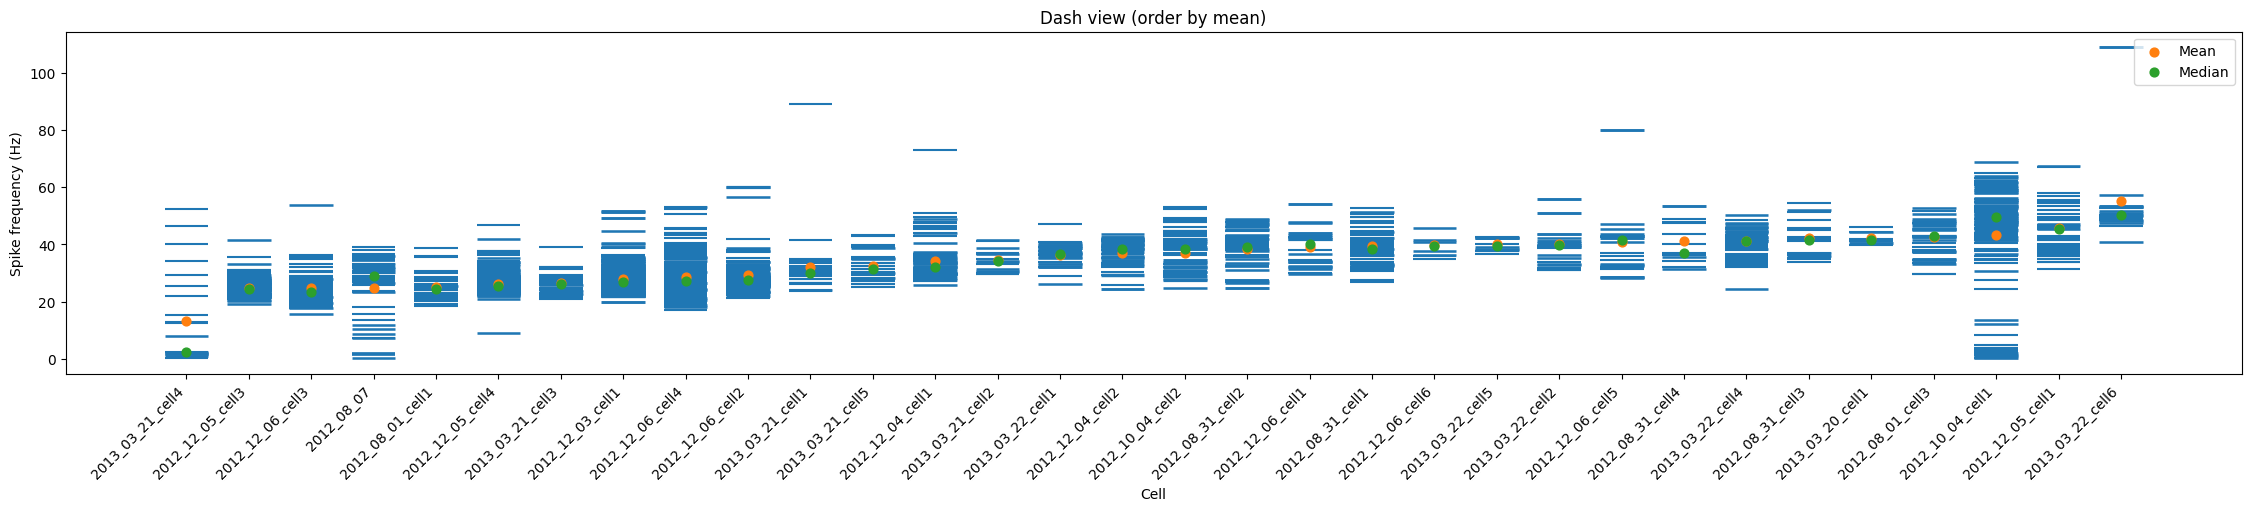

In [7]:
plot_spike_dashes(all_spikes, order_by="mean")

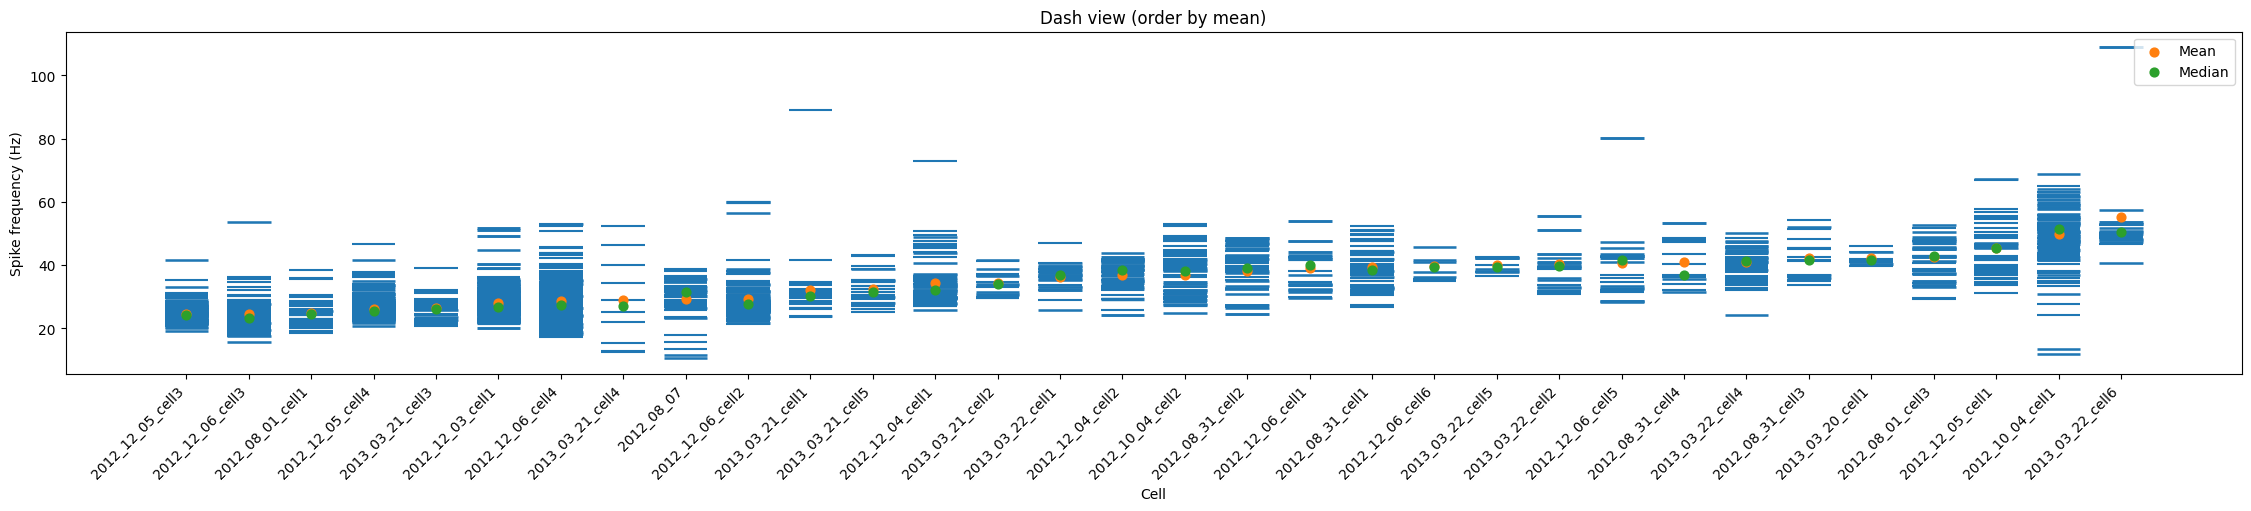

In [15]:
all_spikes_clean = clean_spikes_dataframe(all_spikes, min_freq=10)

plot_spike_dashes(all_spikes_clean, order_by="mean")

In [9]:
all_spikes_clean

,Trace name,trace_time,spike_frequency,burst_index,cell
0,2012_08_01_0002,2.24773,38.550501,3,2012_08_01_cell1
1,2012_08_01_0002,2.28153,25.265285,4,2012_08_01_cell1
2,2012_08_01_0002,2.31920,25.595086,5,2012_08_01_cell1
3,2012_08_01_0002,2.36224,20.746888,6,2012_08_01_cell1
4,2012_08_01_0002,2.40853,24.108004,7,2012_08_01_cell1
...,...,...,...,...,...
3119,2012_10_04_0014,47.51903,60.569352,328,2012_10_04_cell1
3120,2012_10_04_0014,47.52117,60.569352,328,2012_10_04_cell1
3121,2012_10_04_0014,47.54018,49.285362,329,2012_10_04_cell1
3122,2012_10_04_0014,48.10002,49.285362,340,2012_10_04_cell1


In [10]:
# your dict of per-sheet spike tables:
# spikes = assign_spike_frequencies_for_dict(cell_attached_dict)

targets = ["2012_08_07", "2012_10_04_cell1", "2013_03_21_cell4"]

# 1) Apply the filter to each requested sheet (strictly < 5 Hz by default)
low_by_sheet = {}
for name in targets:
    if name not in spikes or not isinstance(spikes[name], pd.DataFrame) or spikes[name].empty:
        print(f"[warn] Sheet '{name}' missing or empty; skipping.")
        continue
    low_by_sheet[name] = find_low_frequency_spikes(spikes[name], threshold=5.0, inclusive=False)

# 2) Print a quick summary count
for name in targets:
    n = 0 if name not in low_by_sheet else len(low_by_sheet[name])
    print(f"{name}: {n} low-freq spikes (< 5 Hz)")

# 3) (Optional) Combine all three into a single DataFrame with a 'sheet' column
combined = []
for name, df_low in low_by_sheet.items():
    if not df_low.empty:
        tmp = df_low.copy()
        tmp["sheet"] = name
        combined.append(tmp)

low_spikes_combined = pd.concat(combined, ignore_index=True) if combined else pd.DataFrame(
    columns=["Trace name", "trace_time", "spike_frequency", "burst_index", "sheet"]
)

# peek
low_spikes_combined
out_path = os.path.join(parent_folder_path, "low_spikes_5Hz_selected_sheets.csv")
low_spikes_combined.to_csv(out_path, index=False)
print("Saved:", out_path)


2012_08_07: 9 low-freq spikes (< 5 Hz)
2012_10_04_cell1: 22 low-freq spikes (< 5 Hz)
2013_03_21_cell4: 13 low-freq spikes (< 5 Hz)
Saved: /Users/Haley/Desktop/low_spikes_5Hz_selected_sheets.csv


In [16]:
cell_types_df = pd.read_csv(parent_folder_path+"murray-neuroscience-lab/Excel processor/List of cells.csv")
cell_types_df = cell_types_df.dropna(how='all')
cell_types_df = cell_types_df.iloc[:,:4]
cell_types_df.reset_index(drop=True,inplace=True)
cell_types_df

,Cell,Cell Type,Input Resistance,Motoneuron
0,2013_03_21_cell5,CaP,33.00,primary
1,2013_03_22_cell6,vRoP,42.00,primary
2,2013_03_22_cell2,CaP,43.64,primary
3,2012_08_31_cell2,vRoP,44.77,primary
4,2012_08_31_cell1,MiP,45.33,primary
5,2012_08_31_cell3,MiP,46.67,primary
6,2013_03_21_cell4,MiP,47.15,primary
7,2012_08_01_cell3,MiP,49.99,primary
8,2013_03_22_cell1,CaP,51.00,primary
9,2013_03_20_cell1,MiP,51.10,primary


In [19]:
summary.to_csv('summary_spikes.csv', index=False)

In [17]:
# your inputs:
# all_spikes: per-spike DF with at least ['cell','spike_frequency', ...]
# cell_meta:  one row per sheet/cell with ['sheet','group','Cell Type','Input Resistance']

# Build the combined summary table
summary, diag = build_cell_summary_with_meta(all_spikes_clean, cell_types_df,
                                             spikes_cell_col="cell",   # or 'sheet' if that's your column
                                             meta_key_col="Cell",
                                             how="inner",
                                             round_decimals=2)

print(summary.head())
print("Cells in spikes but missing meta:", diag["cells_missing_meta"])
print("Cells in meta but missing spikes:", diag["cells_missing_spikes"])

# If you want your plotting functions to order by group->type->Rin:
all_spikes_enriched = enrich_all_spikes_with_meta(all_spikes_clean, cell_types_df,
                                                  spikes_cell_col="cell",
                                                  meta_key_col="Cell")
# Now all_spikes_enriched has the columns your 'order_by=\"meta\"' code expects.
# e.g.:
all_spikes_enriched


               cell          Motoneuron Cell Type  Input Resistance   mean  \
0  2012_08_01_cell1  Low Rin Secondary       vSMN            287.00  24.97   
1  2012_08_01_cell3             primary       MiP             49.99  42.55   
2        2012_08_07  Low Rin Secondary       vSMN            219.00  29.31   
3  2012_08_31_cell1             primary       MiP             45.33  39.28   
4  2012_08_31_cell2             primary      vRoP             44.77  38.21   

   median    min    max  total_spikes  
0   24.52  18.47  38.55            41  
1   42.84  29.46  52.69            65  
2   31.48  10.54  38.93            67  
3   38.40  26.93  52.55            64  
4   39.15  24.64  48.71            69  
Cells in spikes but missing meta: ['2012_10_04_cell1', '2012_12_04_cell2', '2012_12_06_cell2', '2012_12_06_cell3', '2012_12_06_cell5', '2012_12_06_cell6', '2013_03_21_cell2']
Cells in meta but missing spikes: ['2012_04_25_cell1', '2012_04_25_cell3', '2012_06_29', '2013_03_22_cell3']


,Trace name,trace_time,spike_frequency,burst_index,cell,Motoneuron,Cell Type,Input Resistance
0,2012_08_01_0002,2.24773,38.550501,3,2012_08_01_cell1,Low Rin Secondary,vSMN,287.0
1,2012_08_01_0002,2.28153,25.265285,4,2012_08_01_cell1,Low Rin Secondary,vSMN,287.0
2,2012_08_01_0002,2.31920,25.595086,5,2012_08_01_cell1,Low Rin Secondary,vSMN,287.0
3,2012_08_01_0002,2.36224,20.746888,6,2012_08_01_cell1,Low Rin Secondary,vSMN,287.0
4,2012_08_01_0002,2.40853,24.108004,7,2012_08_01_cell1,Low Rin Secondary,vSMN,287.0
...,...,...,...,...,...,...,...,...
3130,2012_10_04_0014,47.51903,60.569352,328,2012_10_04_cell1,NaN,NaN,NaN
3131,2012_10_04_0014,47.52117,60.569352,328,2012_10_04_cell1,NaN,NaN,NaN
3132,2012_10_04_0014,47.54018,49.285362,329,2012_10_04_cell1,NaN,NaN,NaN
3133,2012_10_04_0014,48.10002,49.285362,340,2012_10_04_cell1,NaN,NaN,NaN


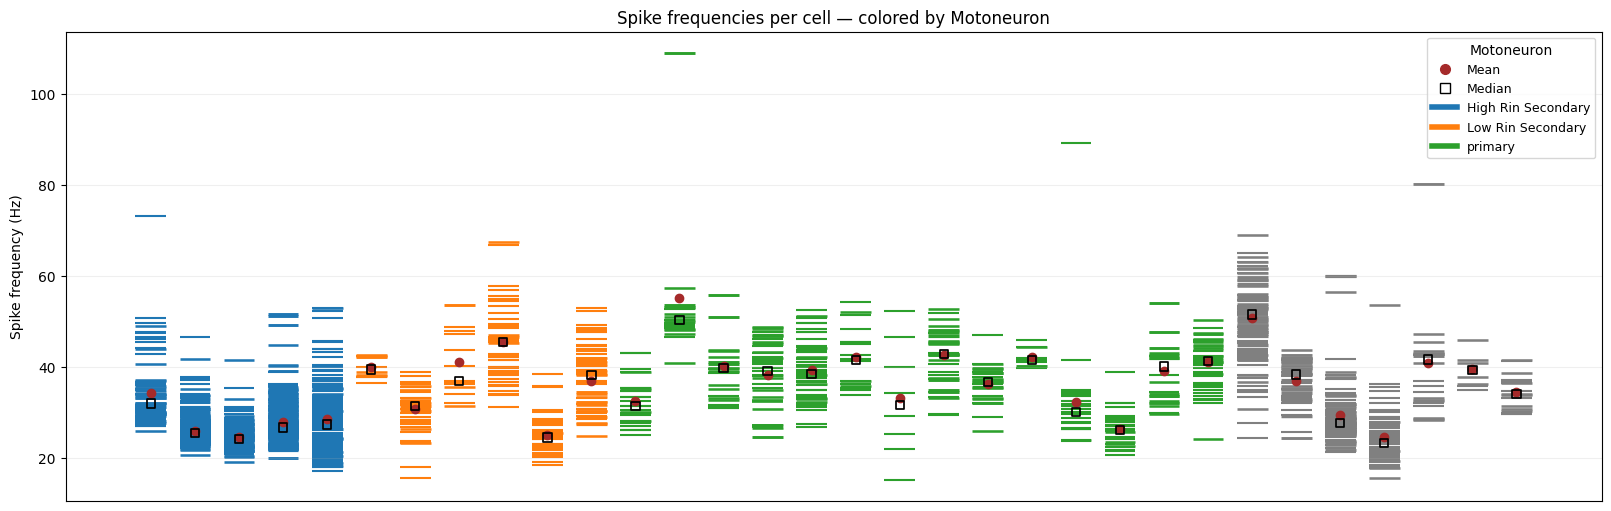

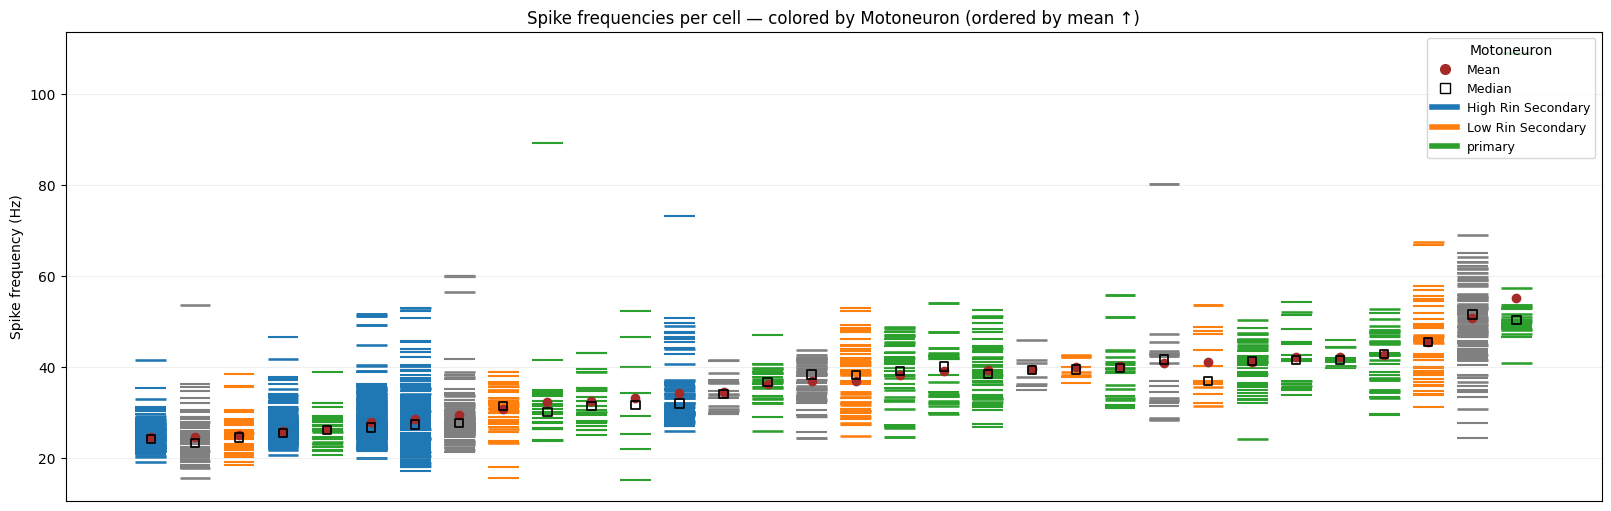

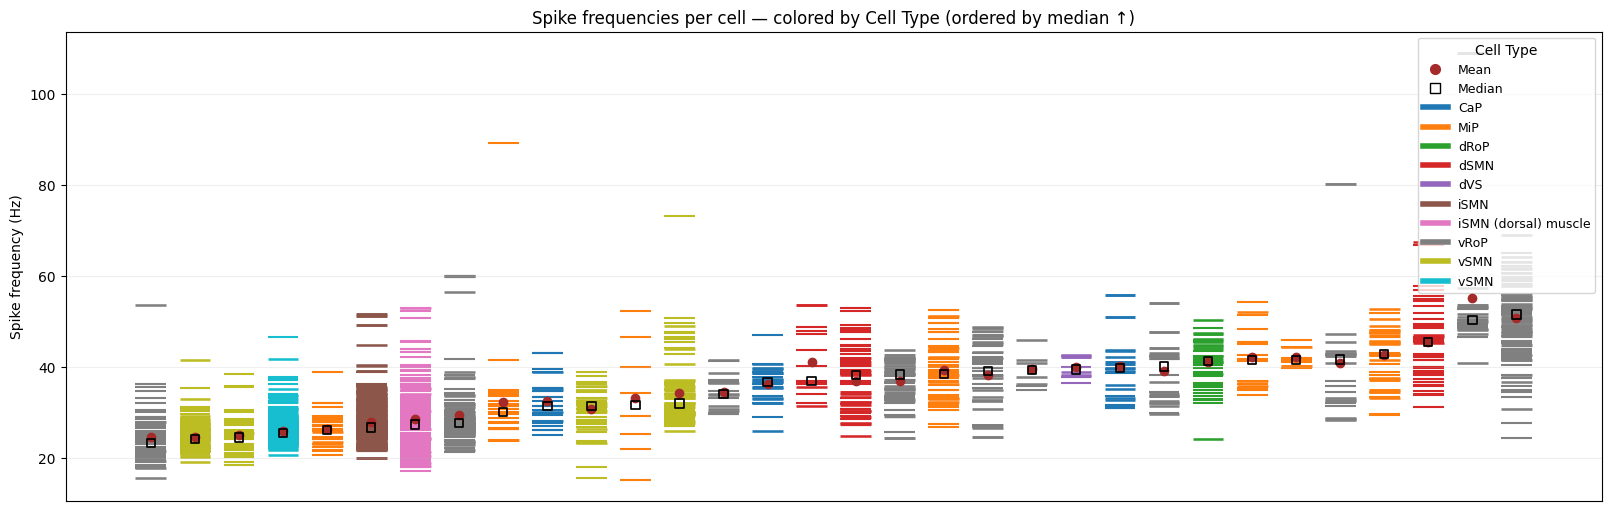

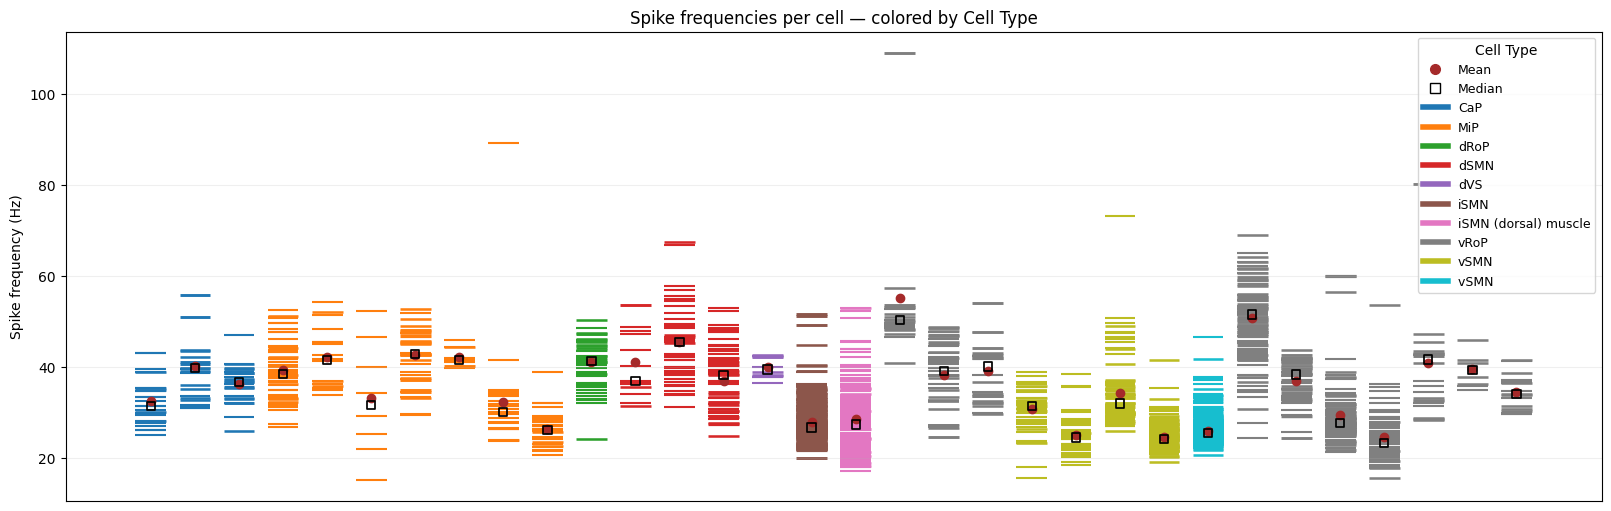

In [13]:
# Color by Motoneuron (default), order by Motoneuron → Cell Type → Rin
plot_spike_dashes_color_by_meta(all_spikes_enriched,  show_group_bands=False, sort_by=("Motoneuron","Input Resistance"), rin_ascending=True)
plot_spike_dashes_color_by_meta(all_spikes_enriched, order_by_freq="mean", freq_ascending=True)


# Color by Cell Type instead
plot_spike_dashes_color_by_meta(all_spikes_enriched, color_by="Cell Type",order_by_freq="median", freq_ascending=True)

# Sort only by Input Resistance (descending), color by Cell Type, no bands
plot_spike_dashes_color_by_meta(
    all_spikes_enriched,
    sort_by=("Cell Type","Input Resistance"),
    color_by="Cell Type",
    rin_ascending=True,
    show_group_bands=False
)


In [14]:
# Example usage with the summary returned by your scatter function:
per_cell, _ = scatter_logrin_vs_median(all_spikes_enriched, color_by=None, fit_line=False)
results = compare_x_transforms(per_cell, rin_col="rin", y_col="median_spike_frequency")
print(results.to_string(index=False))


NameError: name 'scatter_logrin_vs_median' is not defined

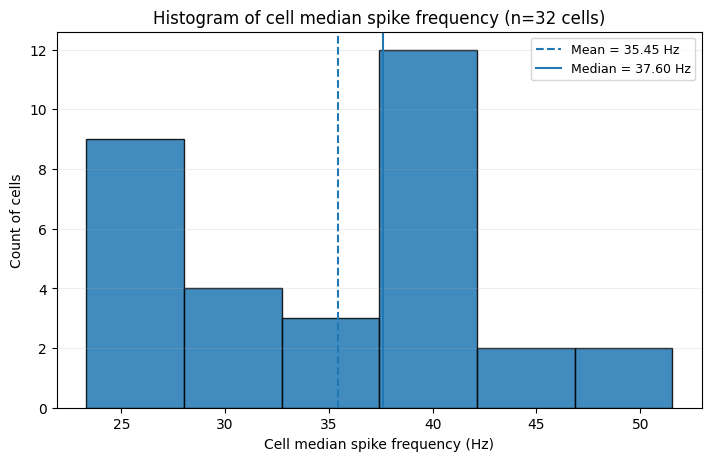

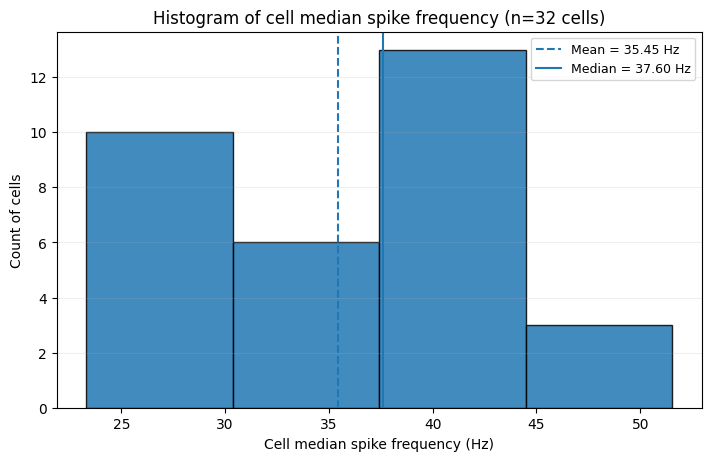

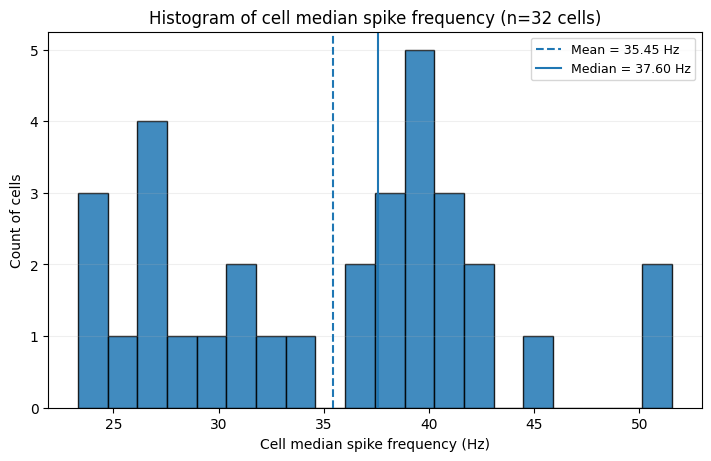

In [ ]:
# Basic
med = histogram_cell_medians(all_spikes_enriched)

# Use Freedman–Diaconis rule for bins
med = histogram_cell_medians(all_spikes_enriched, use_fd_rule=True)

# Fixed number of bins
med = histogram_cell_medians(all_spikes_enriched, bins=20)


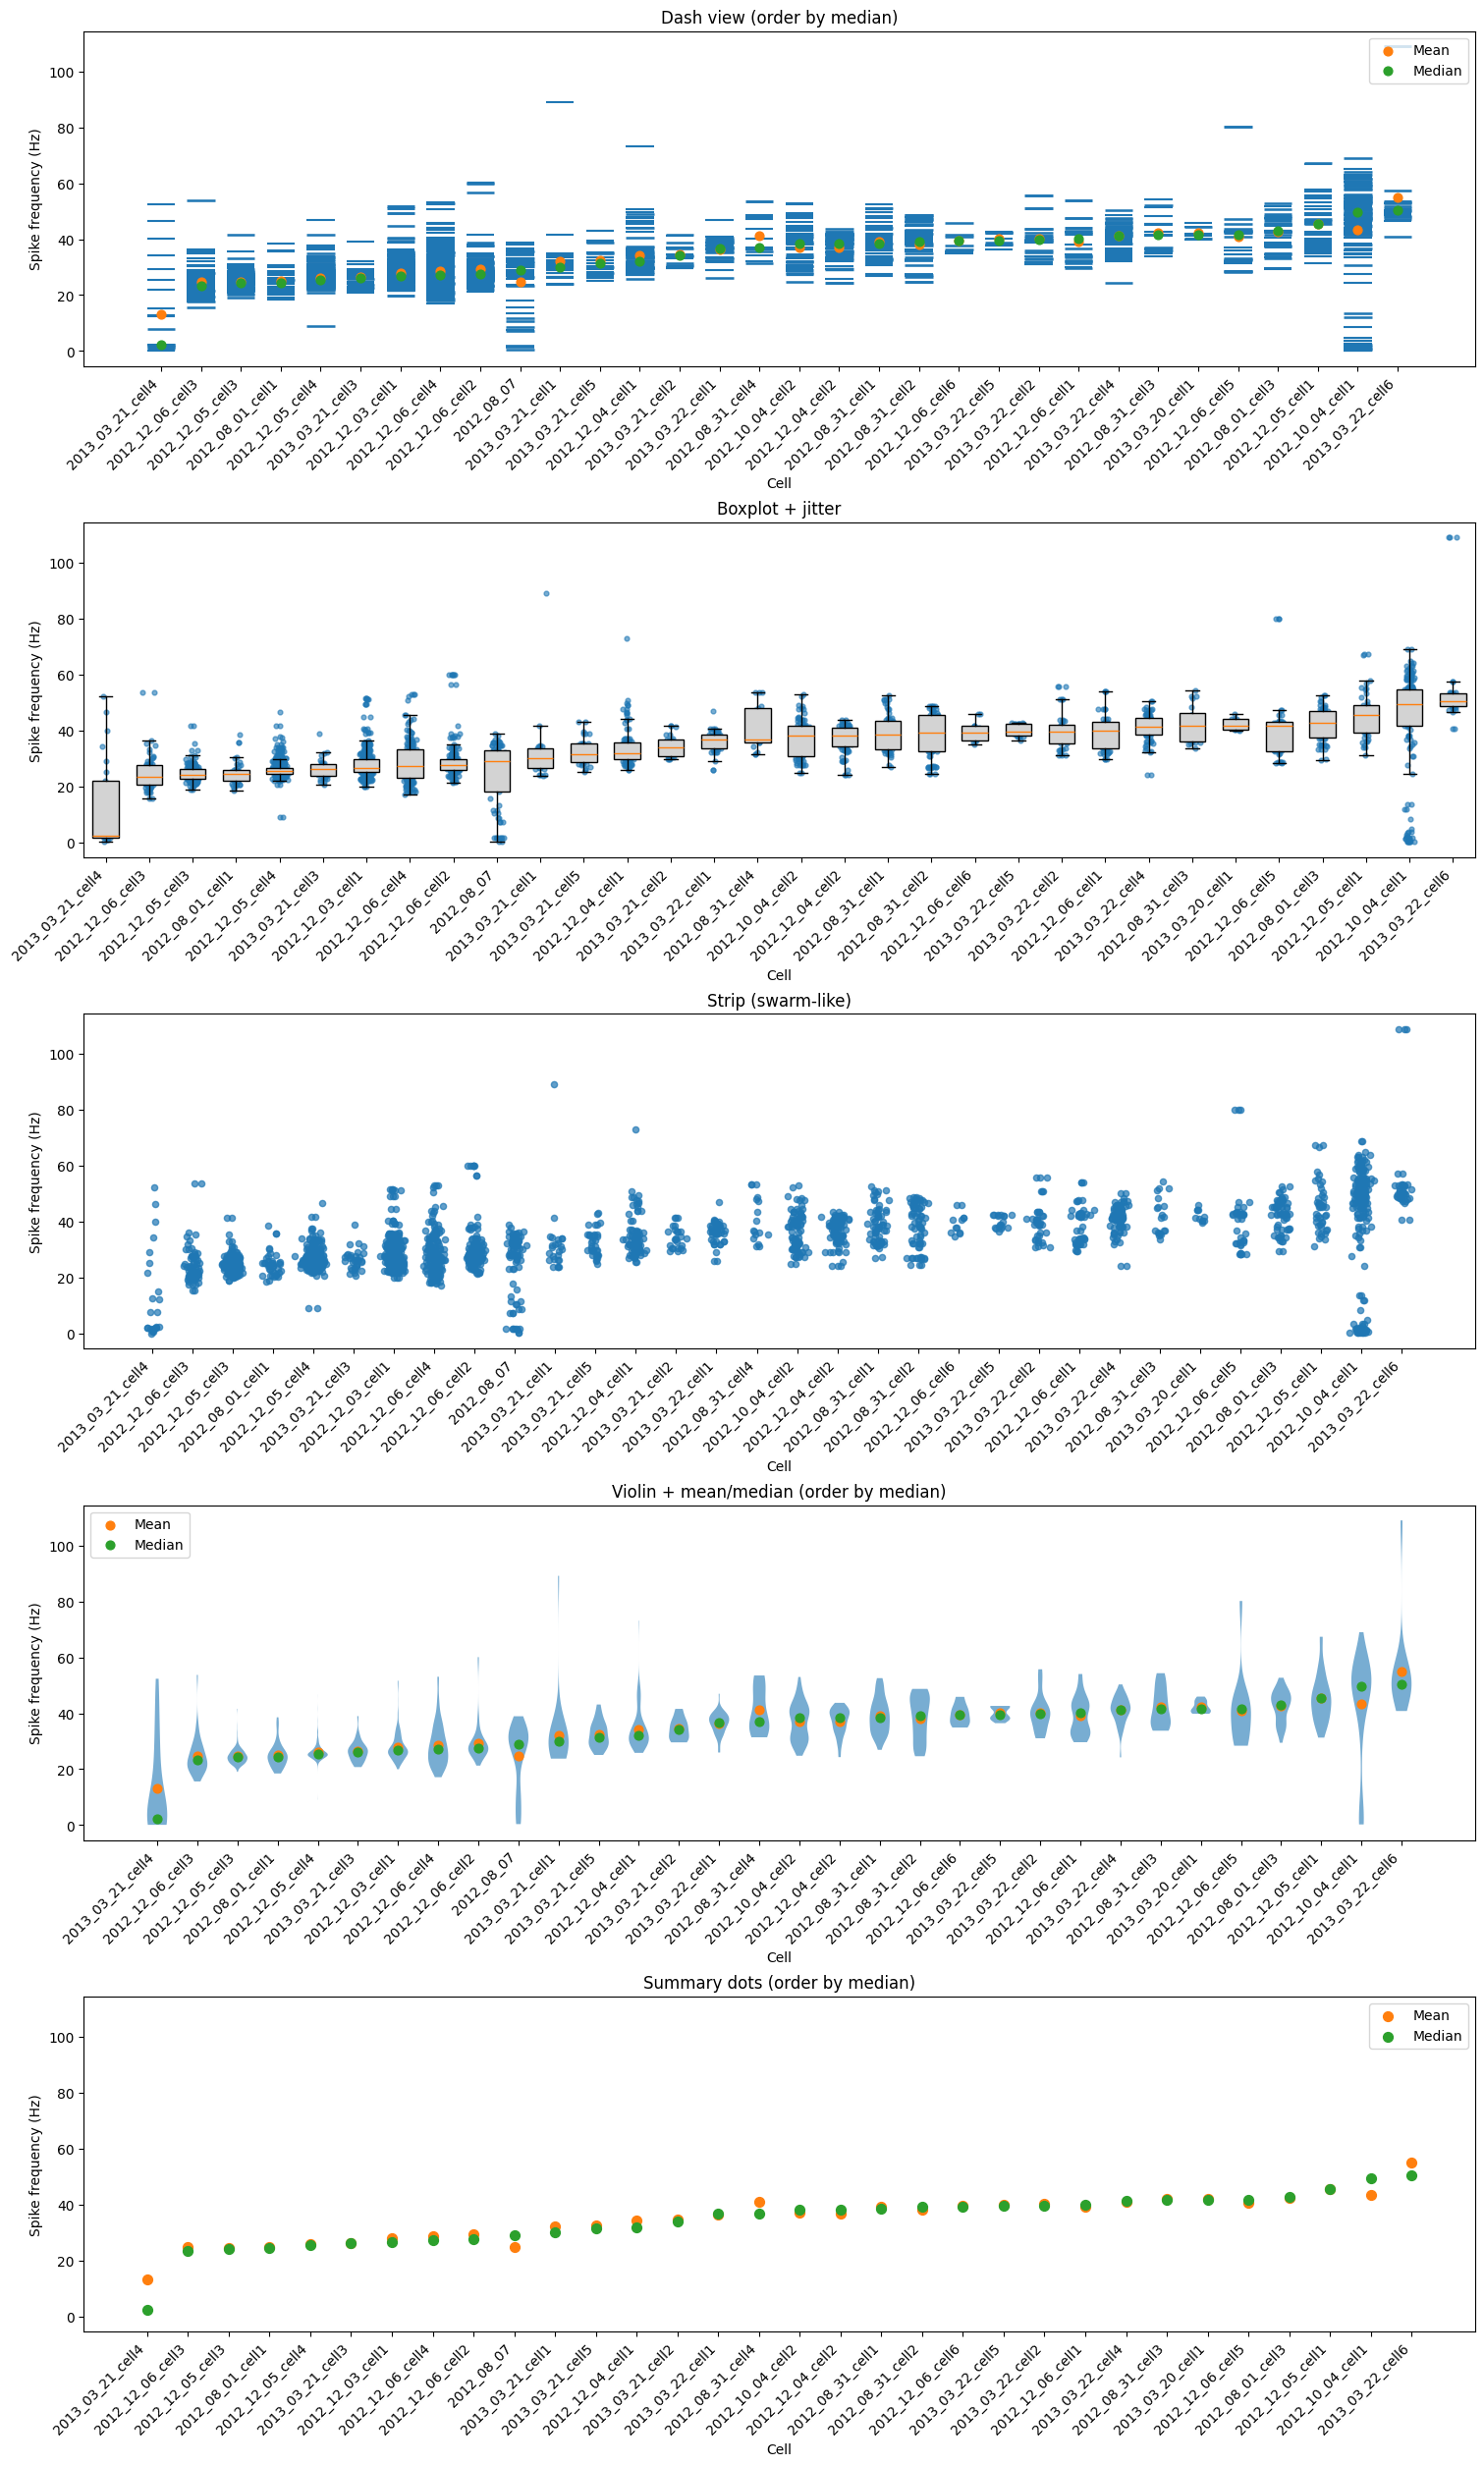

In [ ]:
# Stacked 1×5 grid, order by median
plot_all_views_grid(all_spikes, order_by="median")


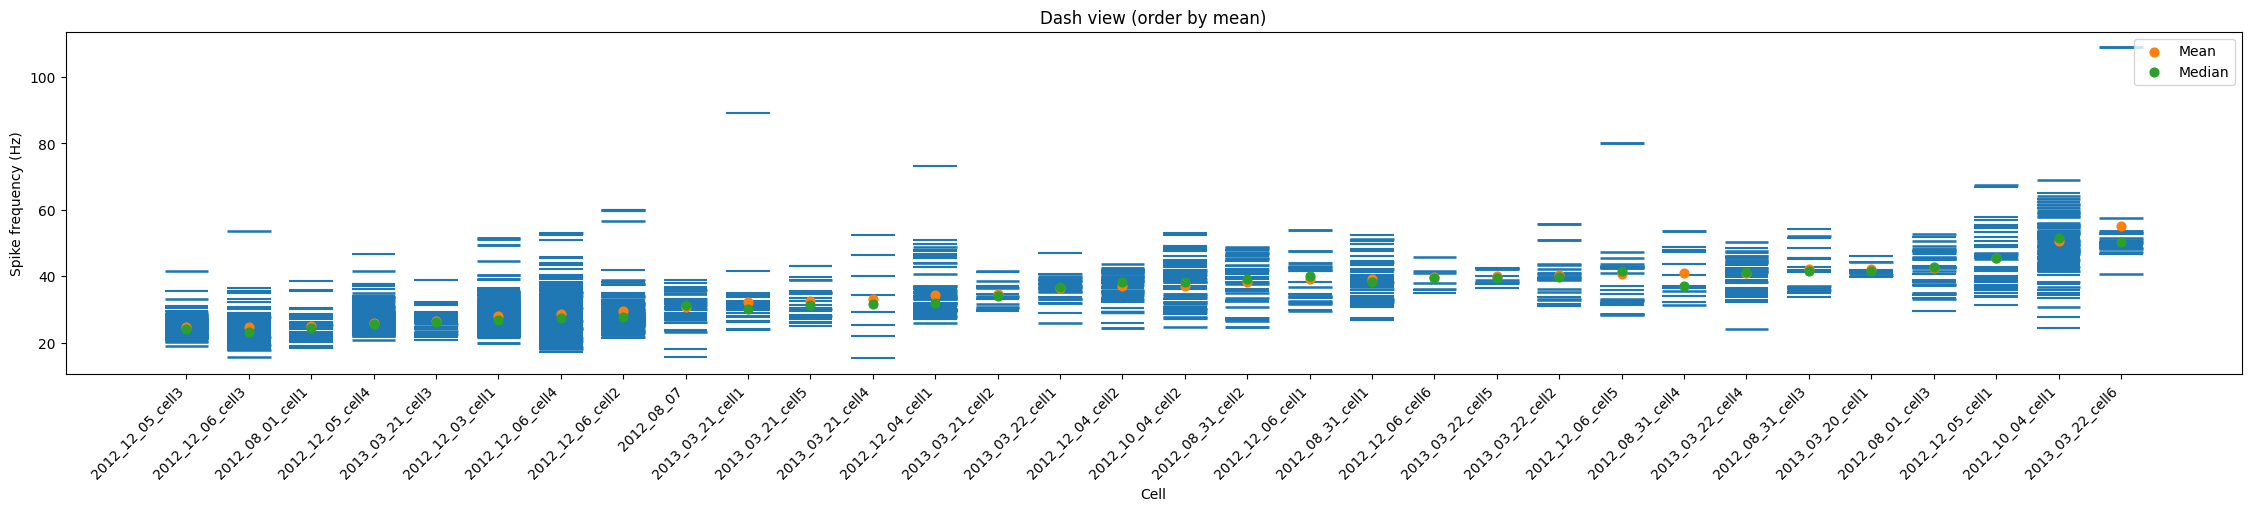

/Users/Haley/Desktop/murray-neuroscience-lab/Cleaned, updated files from Spring/cellattachedspikes.py:691: UserWarning: The figure layout has changed to tight
  


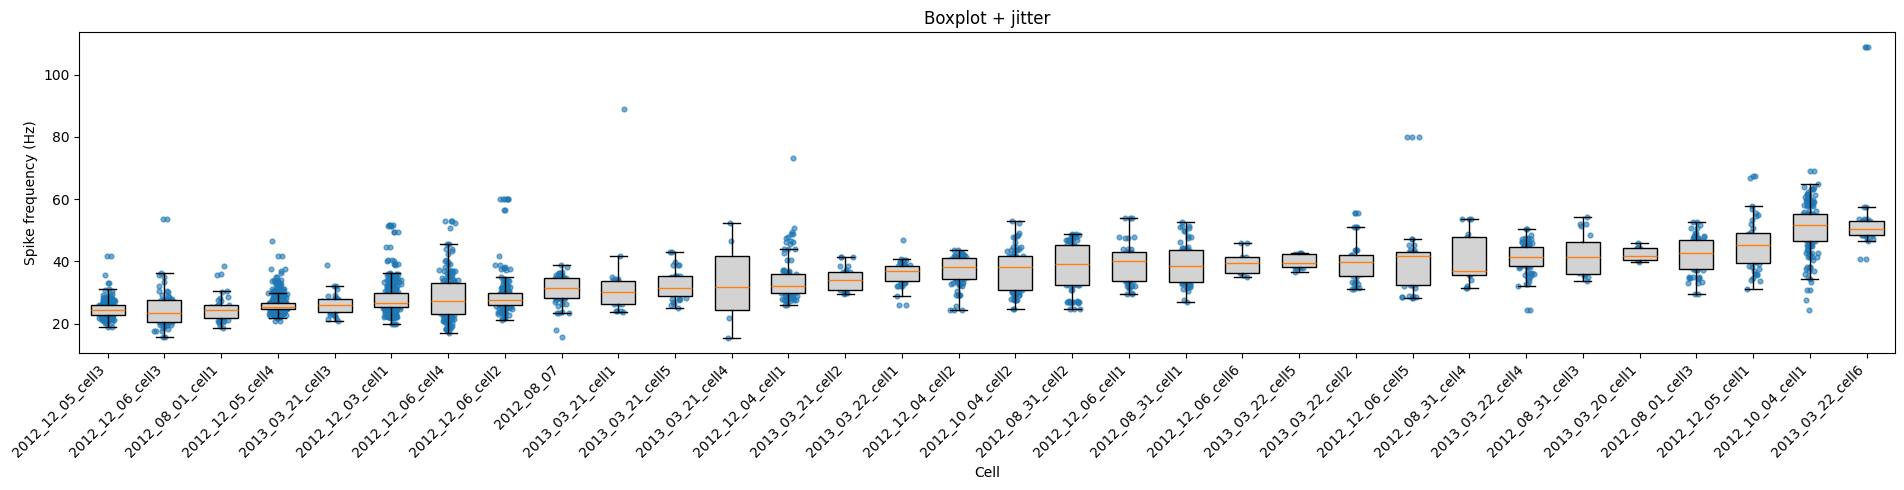

/Users/Haley/Desktop/murray-neuroscience-lab/Cleaned, updated files from Spring/cellattachedspikes.py:718: UserWarning: The figure layout has changed to tight
  for pc in parts["bodies"]:


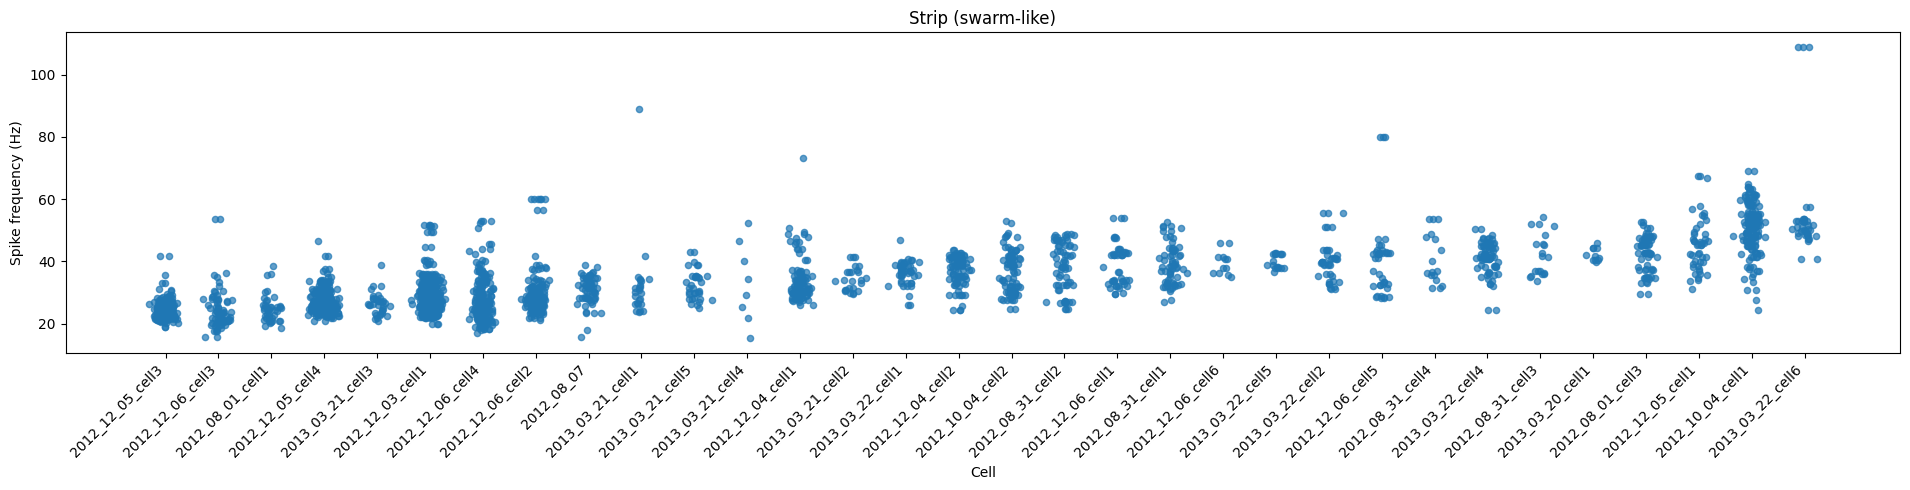

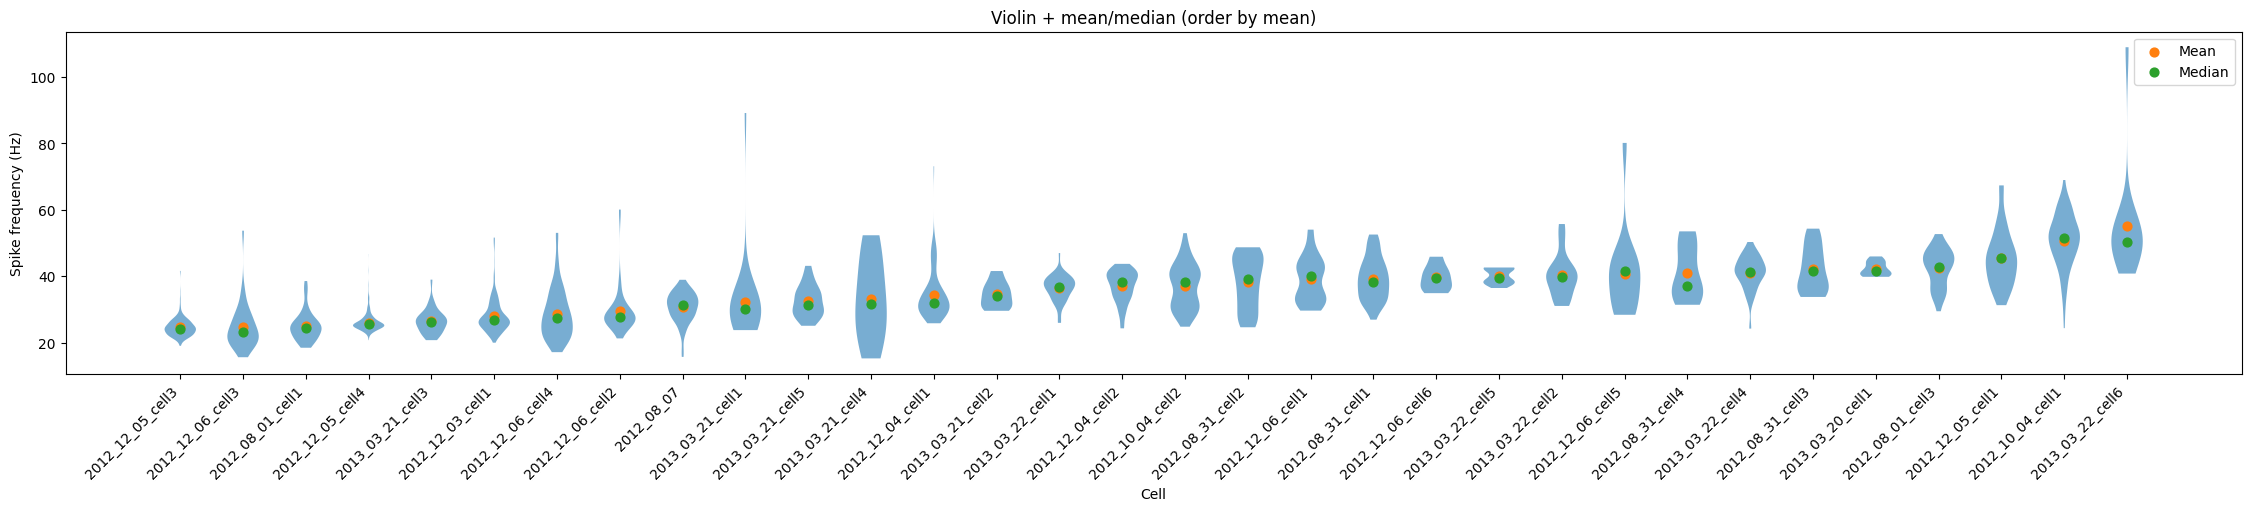

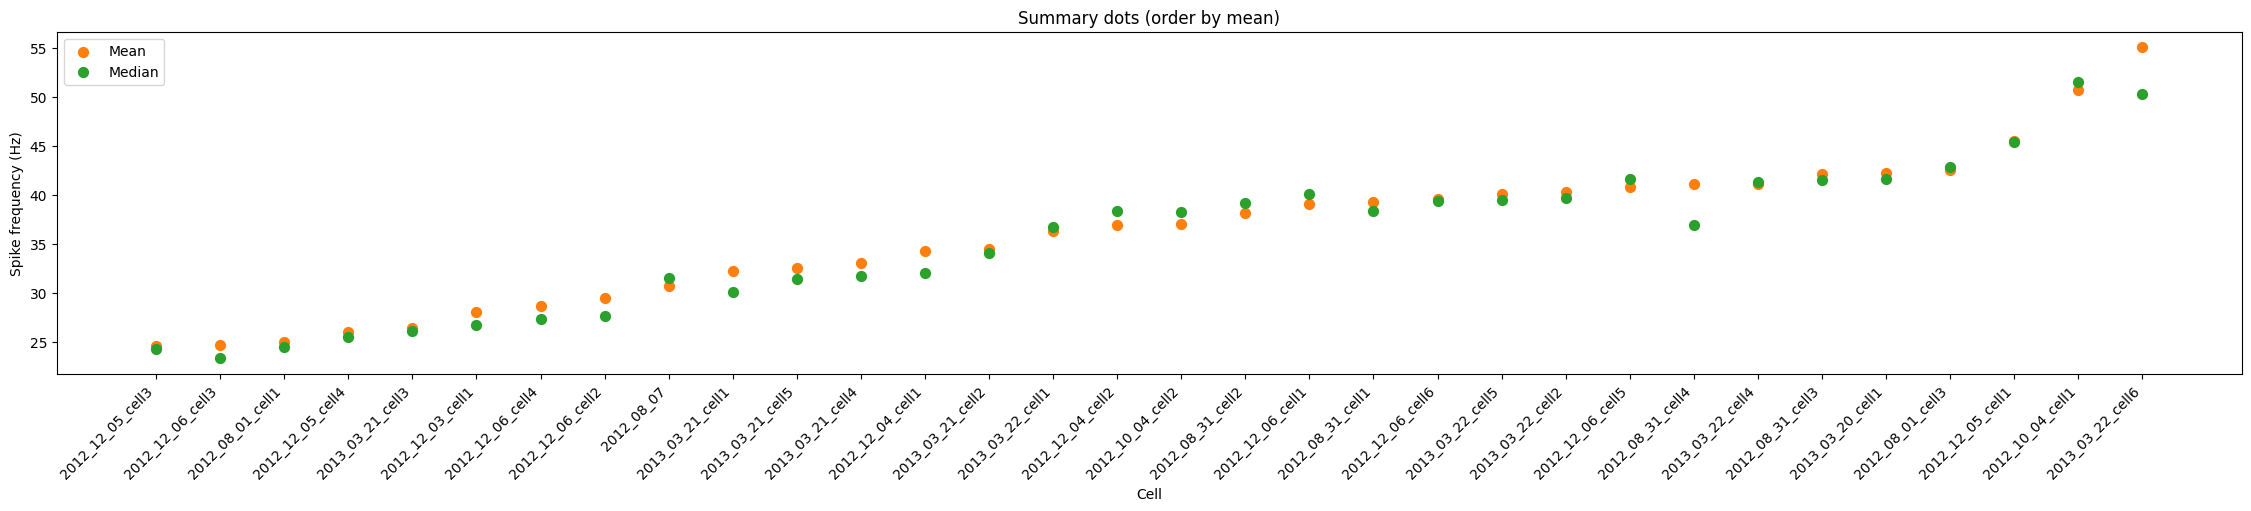

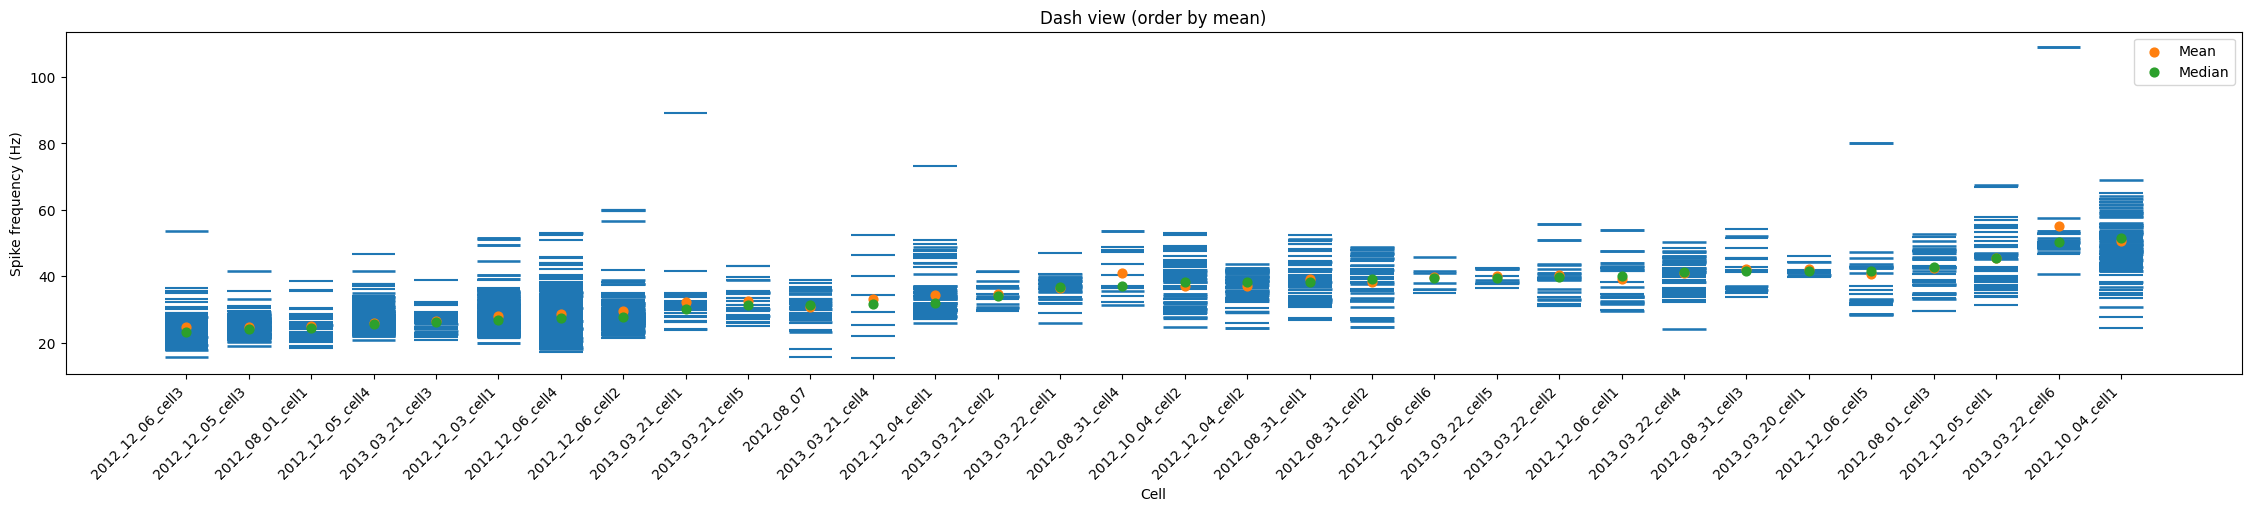

/Users/Haley/Desktop/murray-neuroscience-lab/Cleaned, updated files from Spring/cellattachedspikes.py:691: UserWarning: The figure layout has changed to tight
  


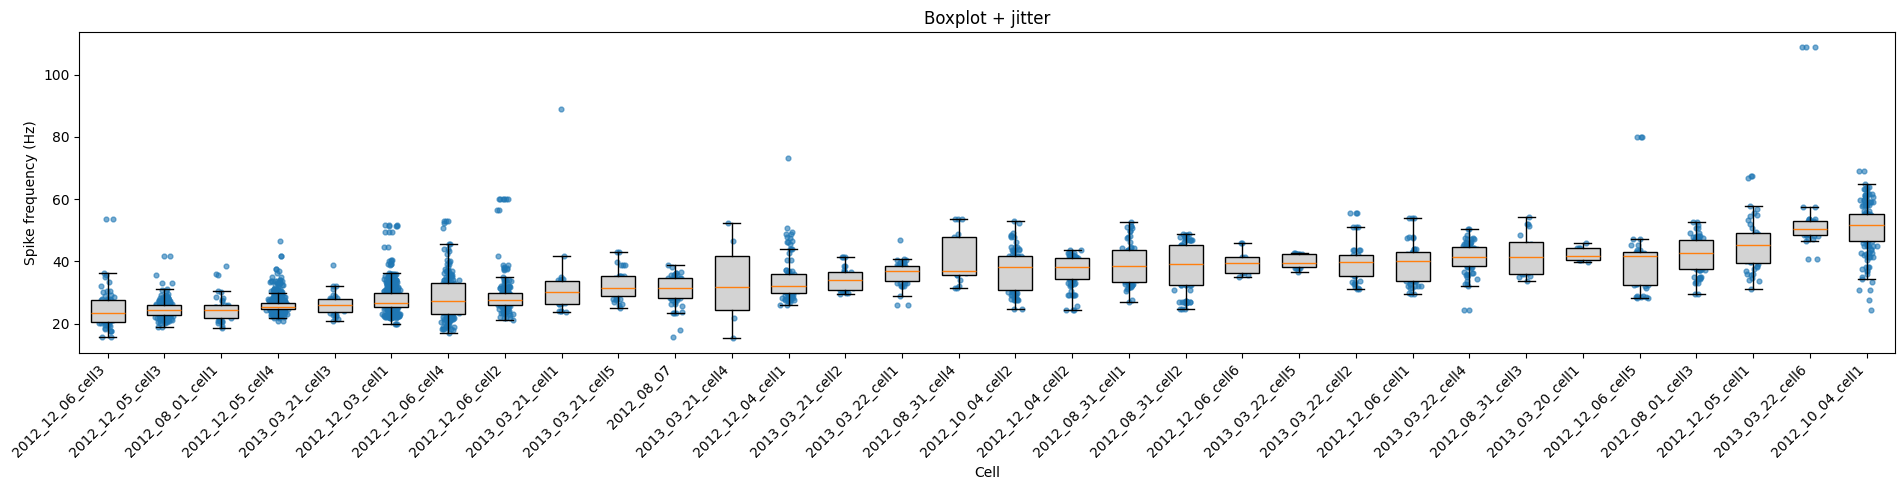

/Users/Haley/Desktop/murray-neuroscience-lab/Cleaned, updated files from Spring/cellattachedspikes.py:718: UserWarning: The figure layout has changed to tight
  for pc in parts["bodies"]:


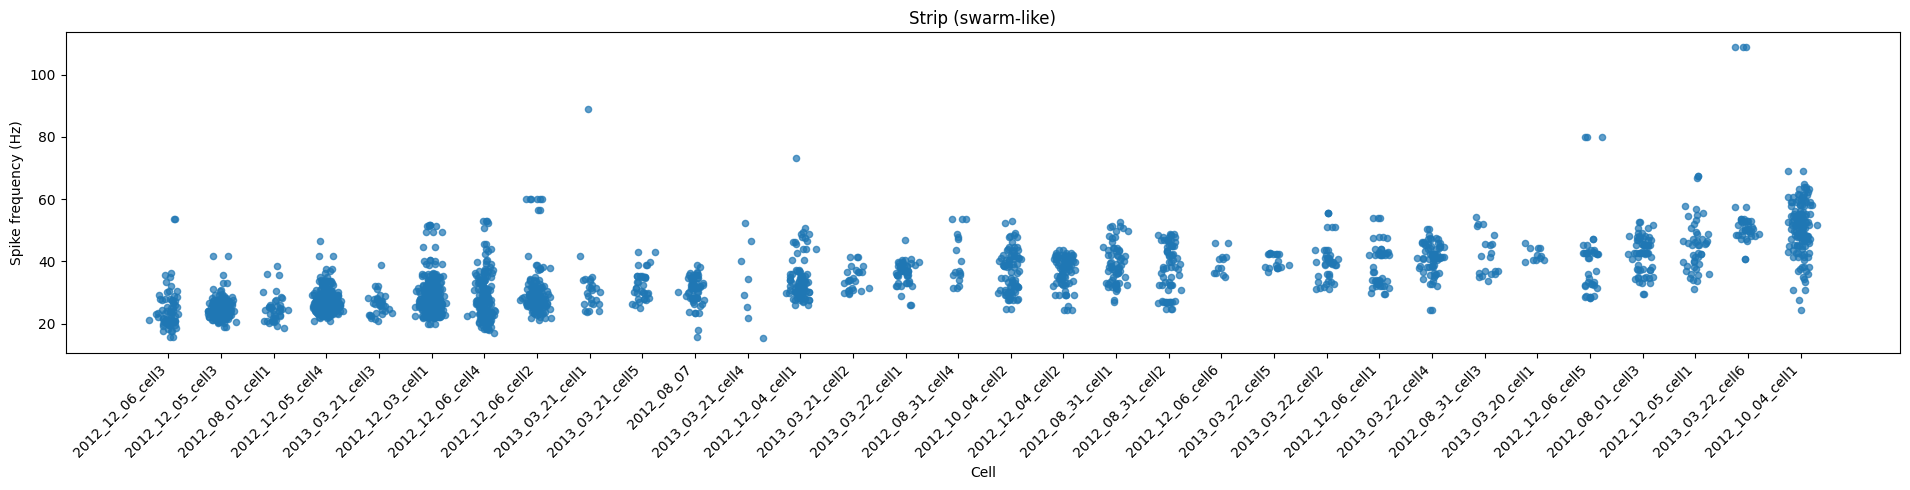

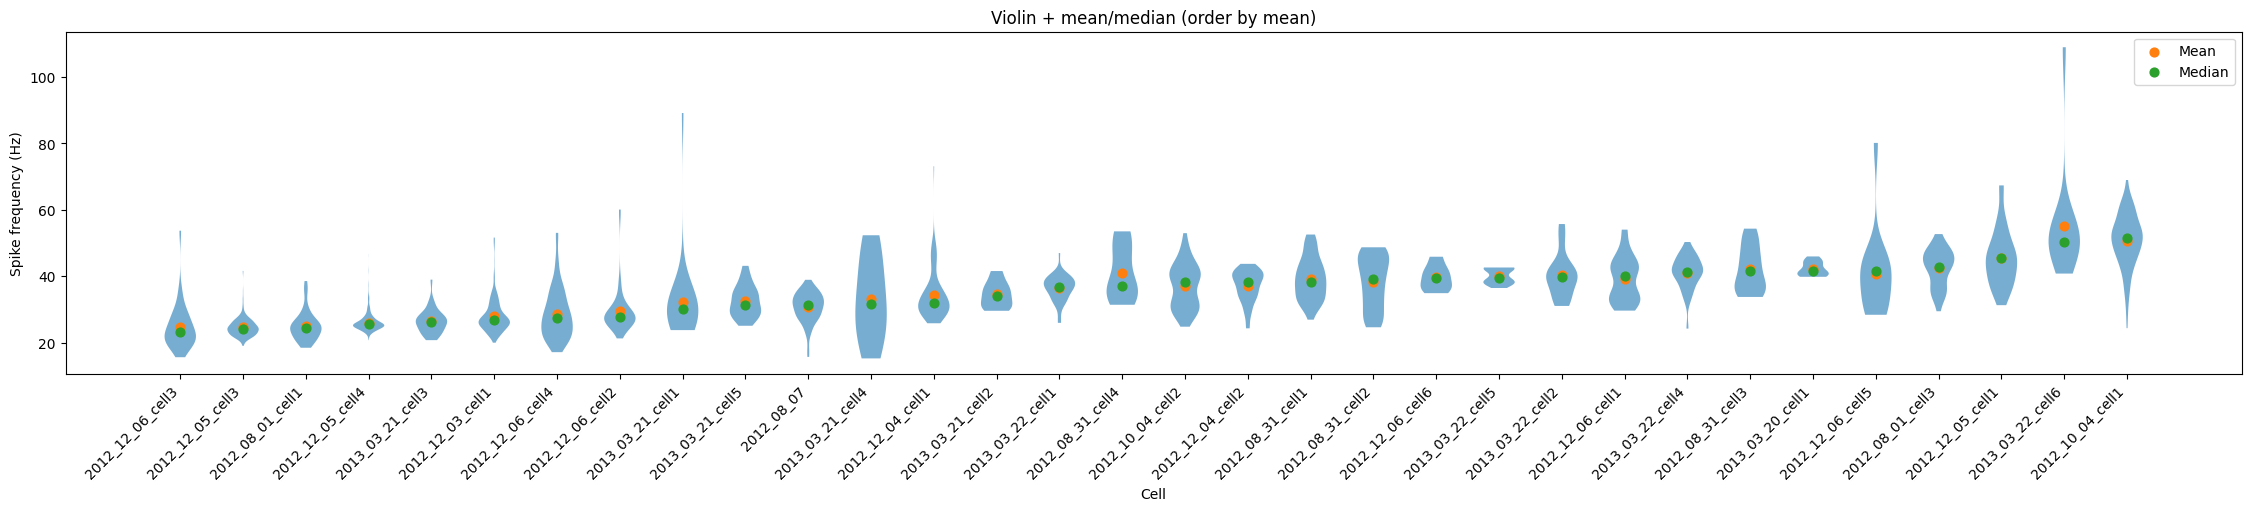

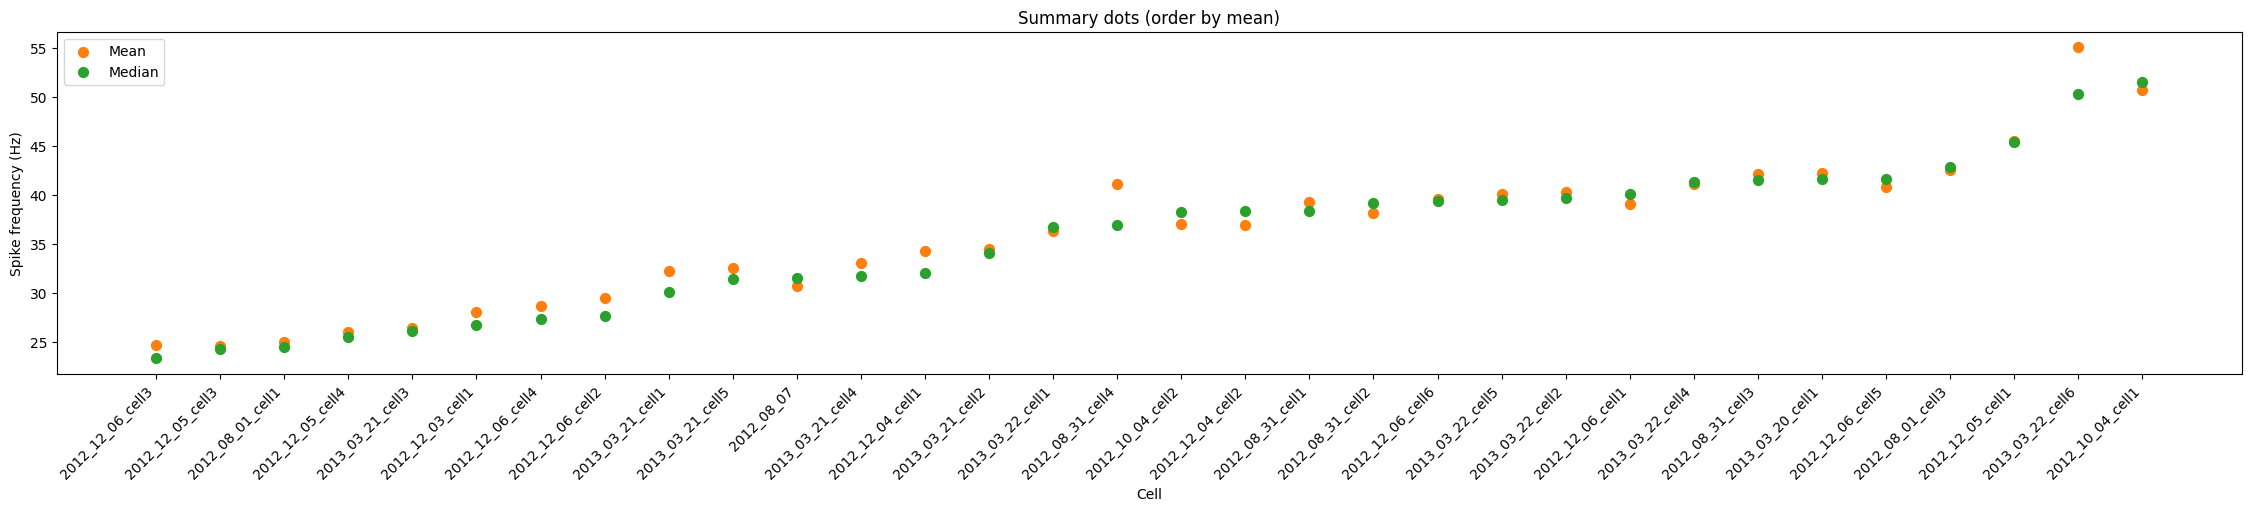

In [ ]:
plot_all_views(all_spikes_clean, order_by="mean")

# Positional (since order_by is 2nd arg)
plot_all_views(all_spikes_clean, "median")



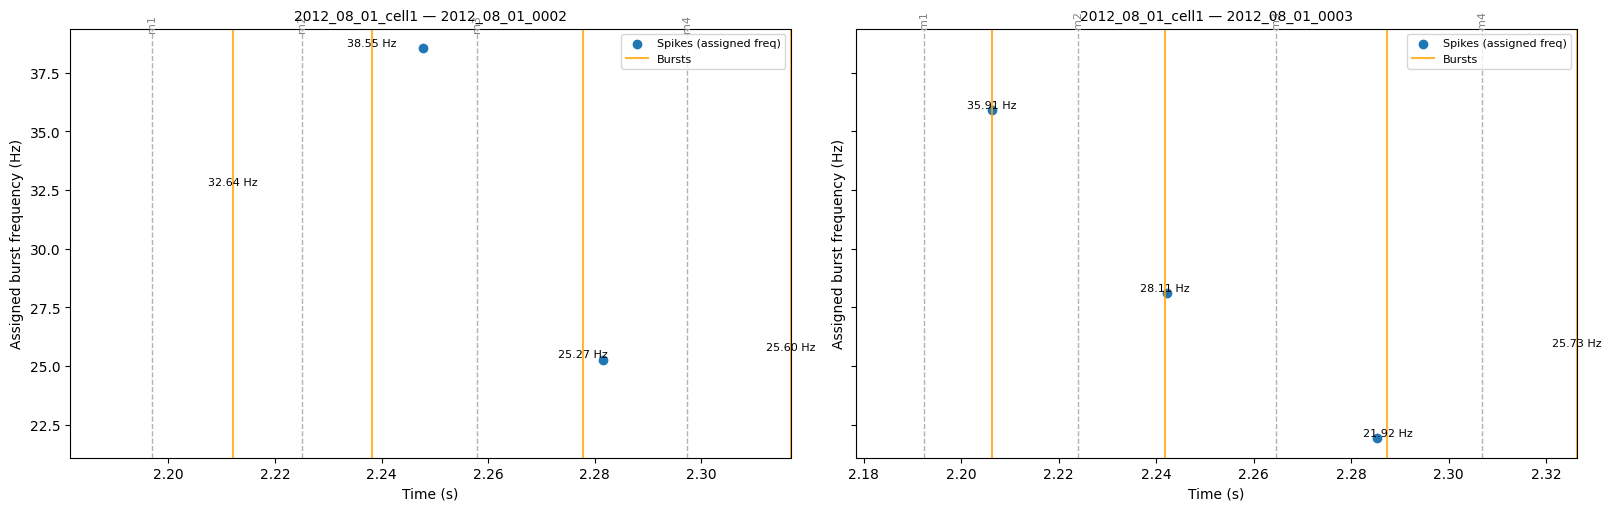

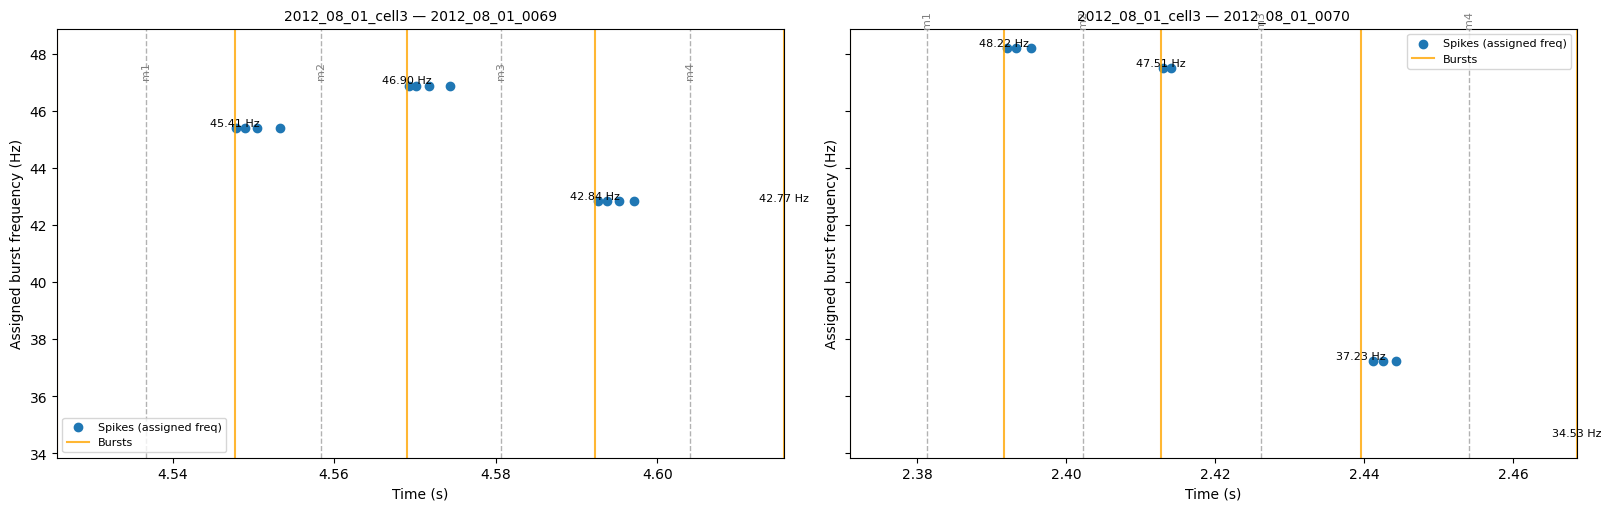

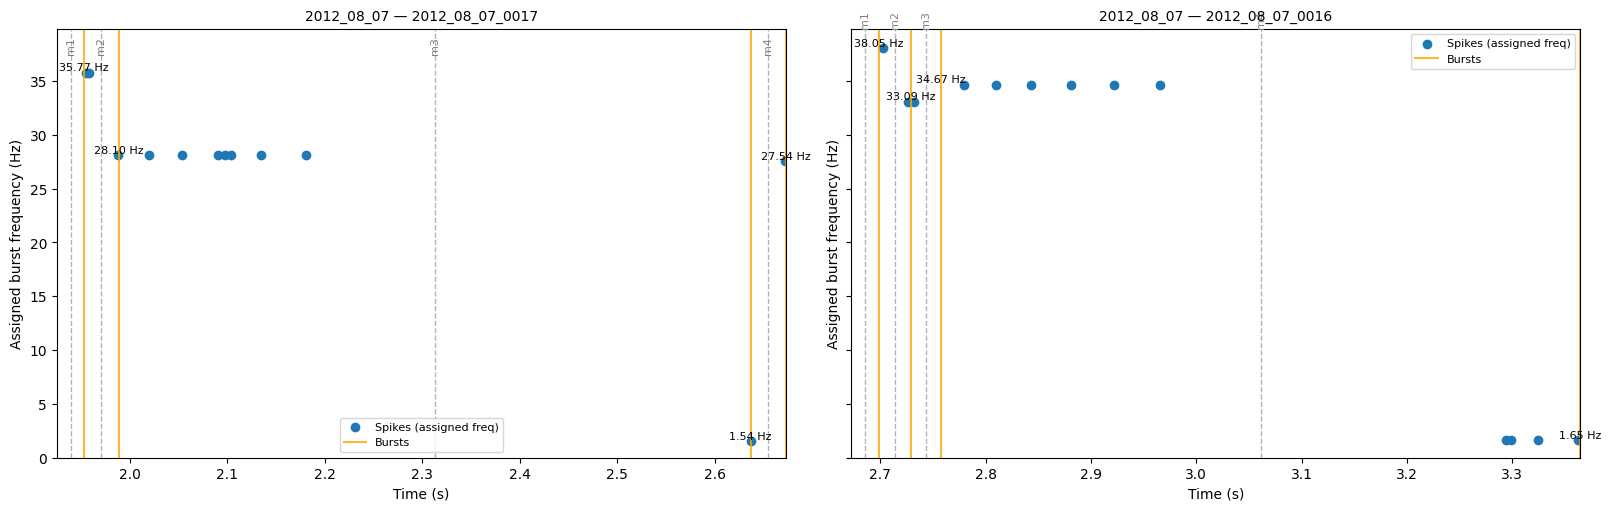

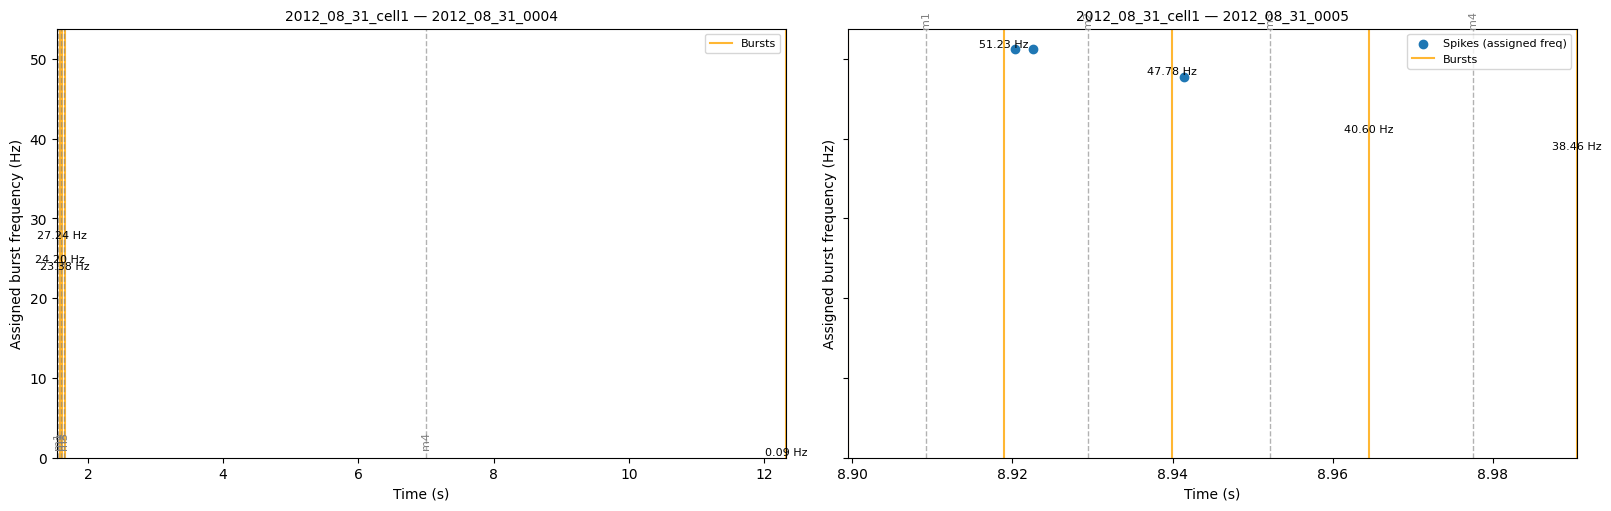

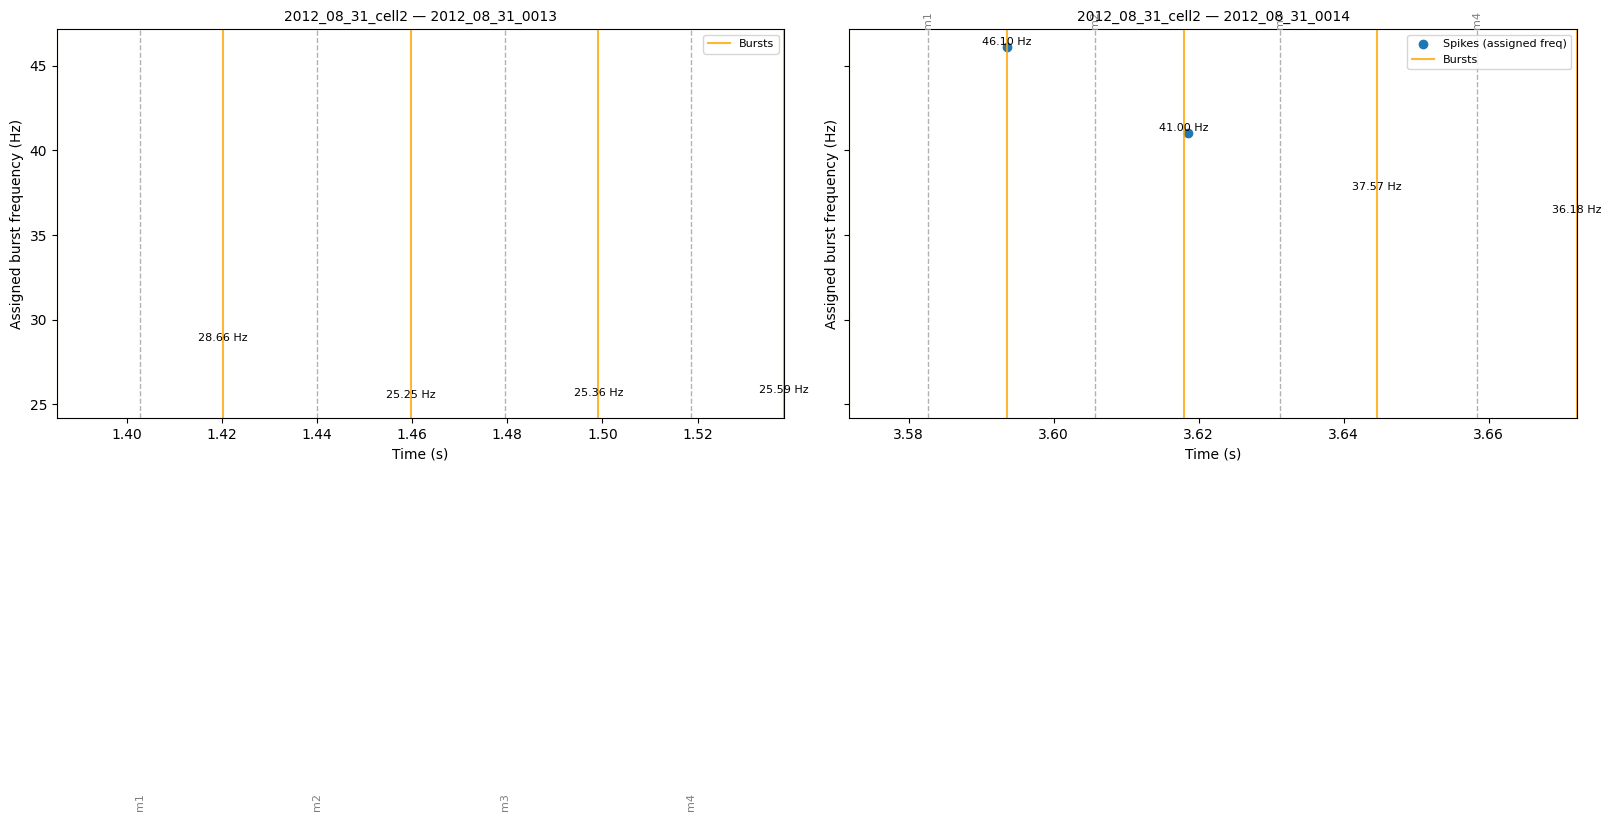

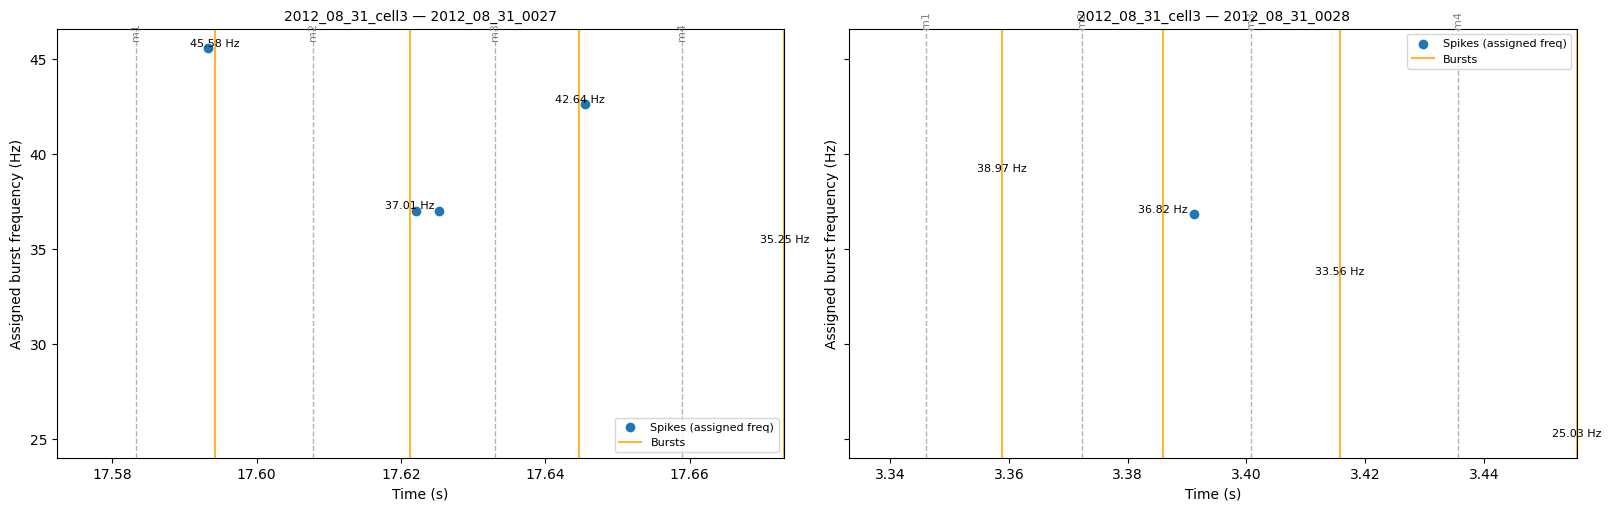

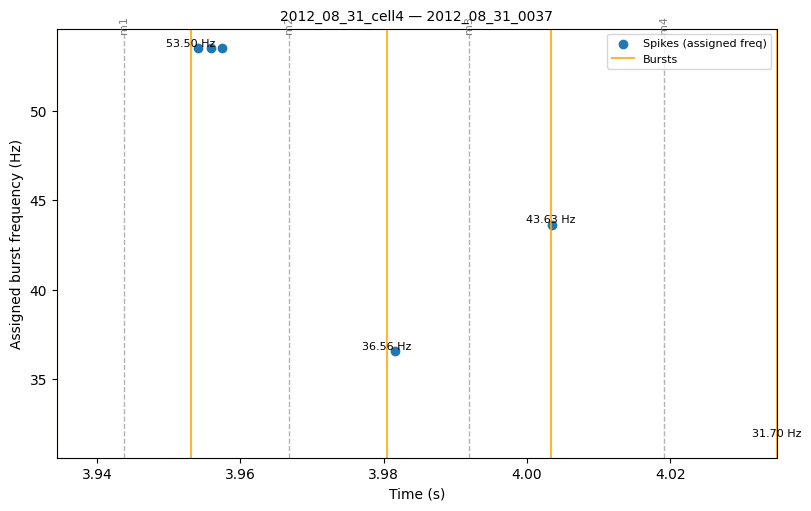

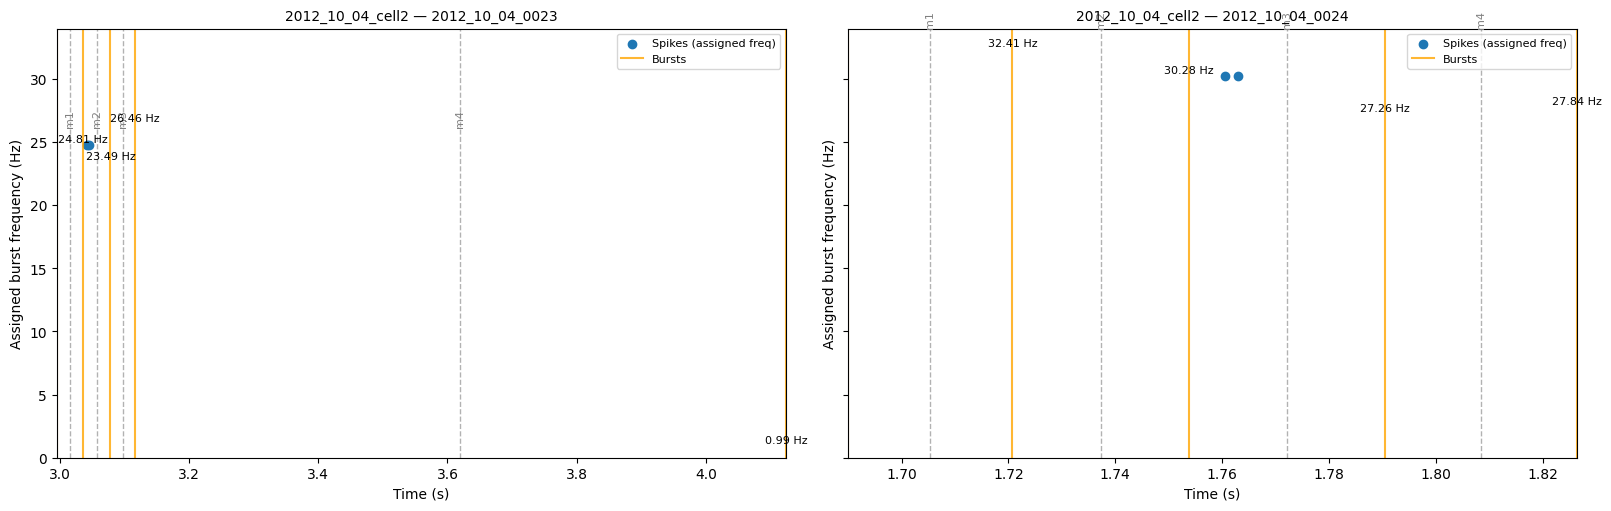

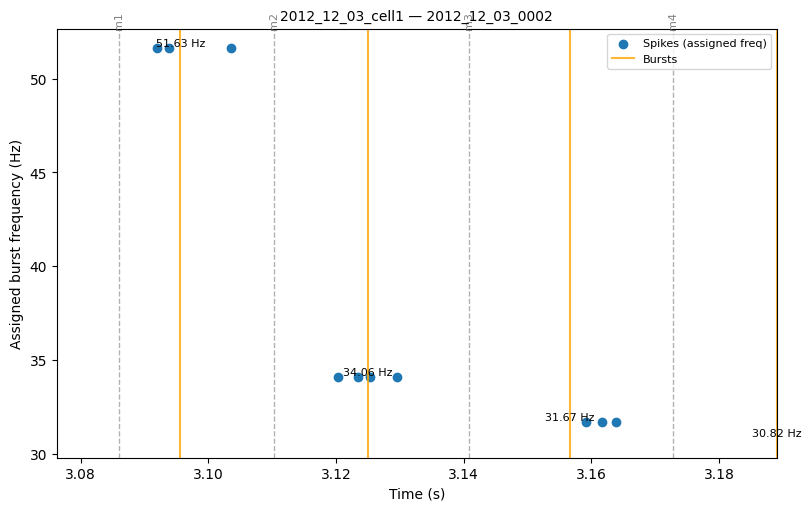

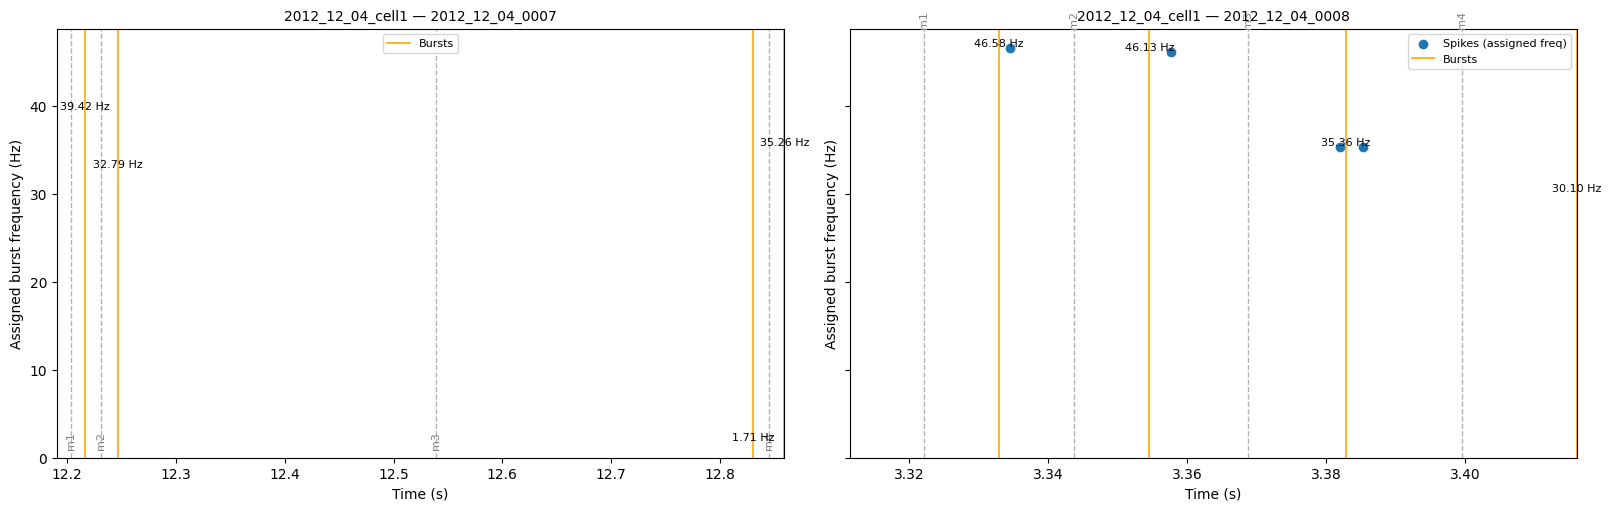

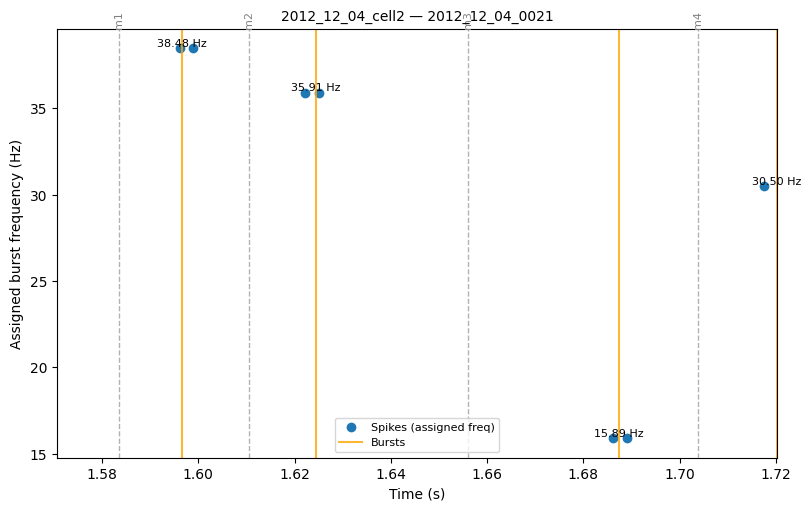

/Users/Haley/Desktop/murray-neuroscience-lab/neuro-venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


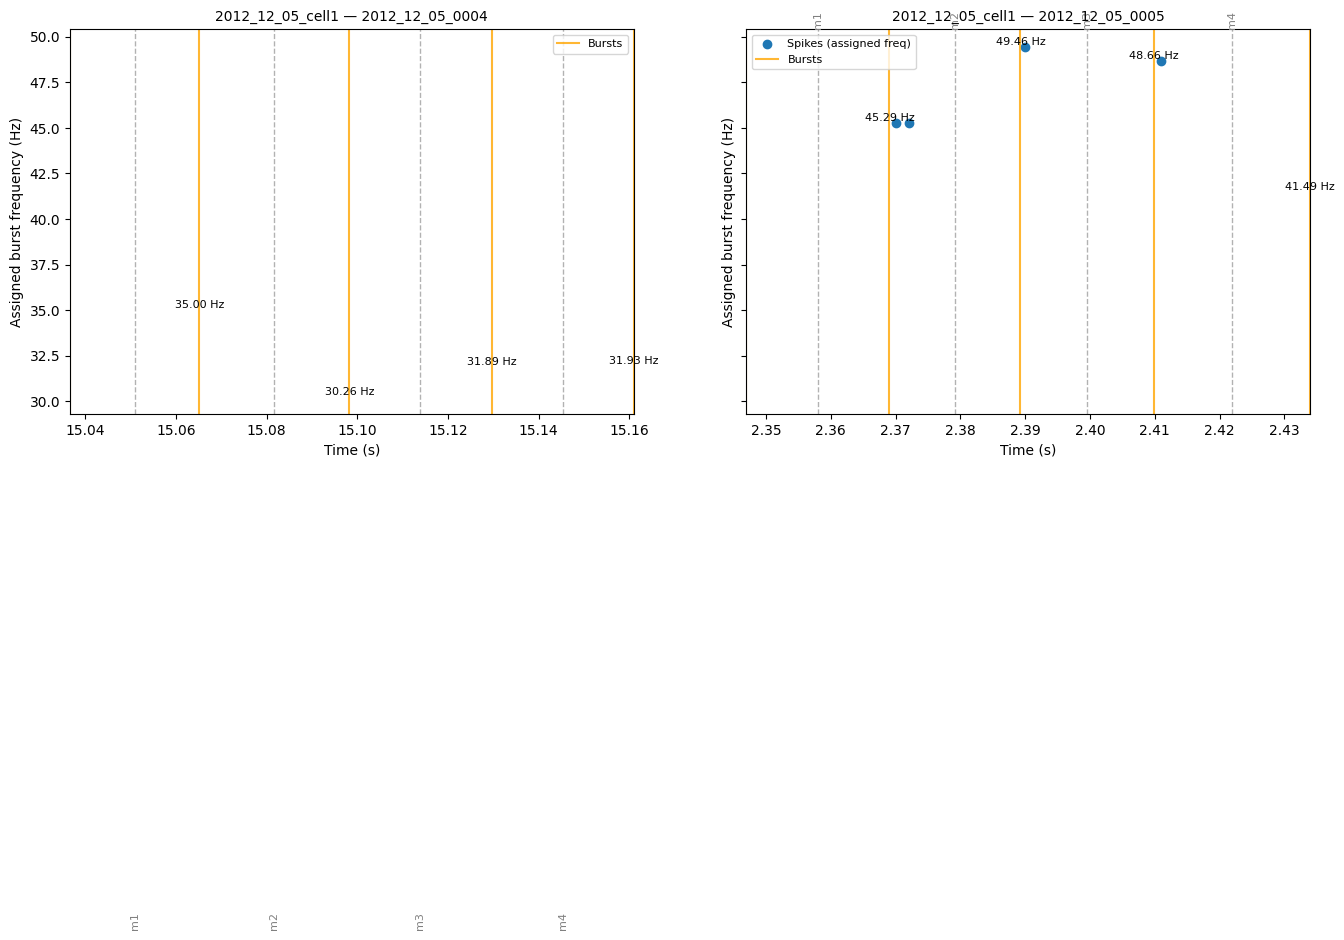

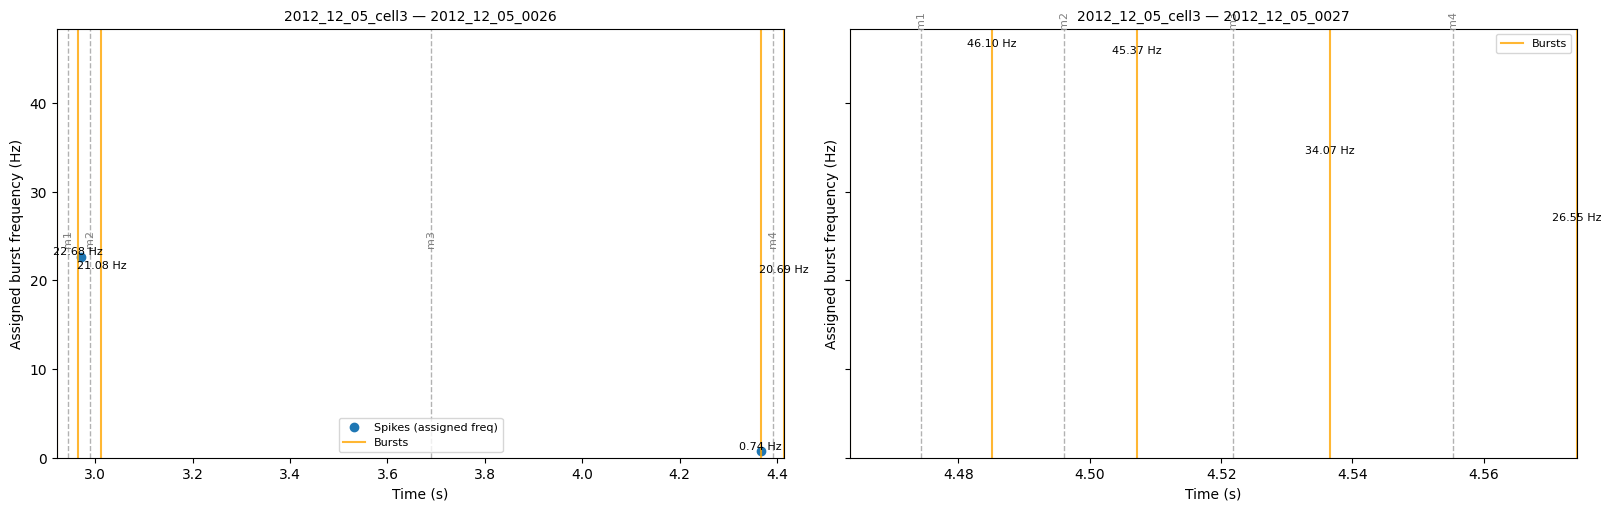

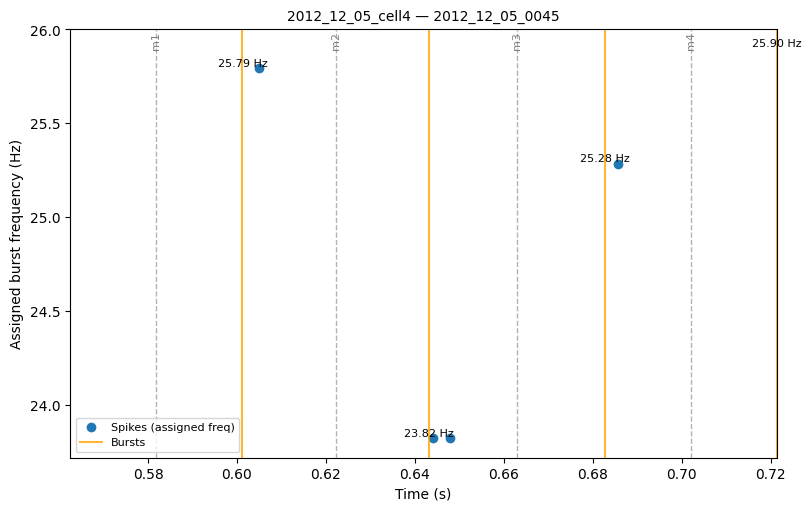

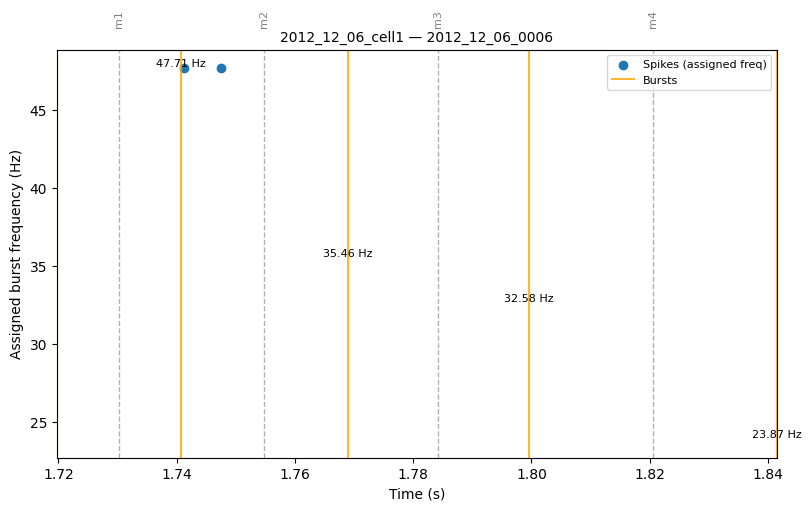

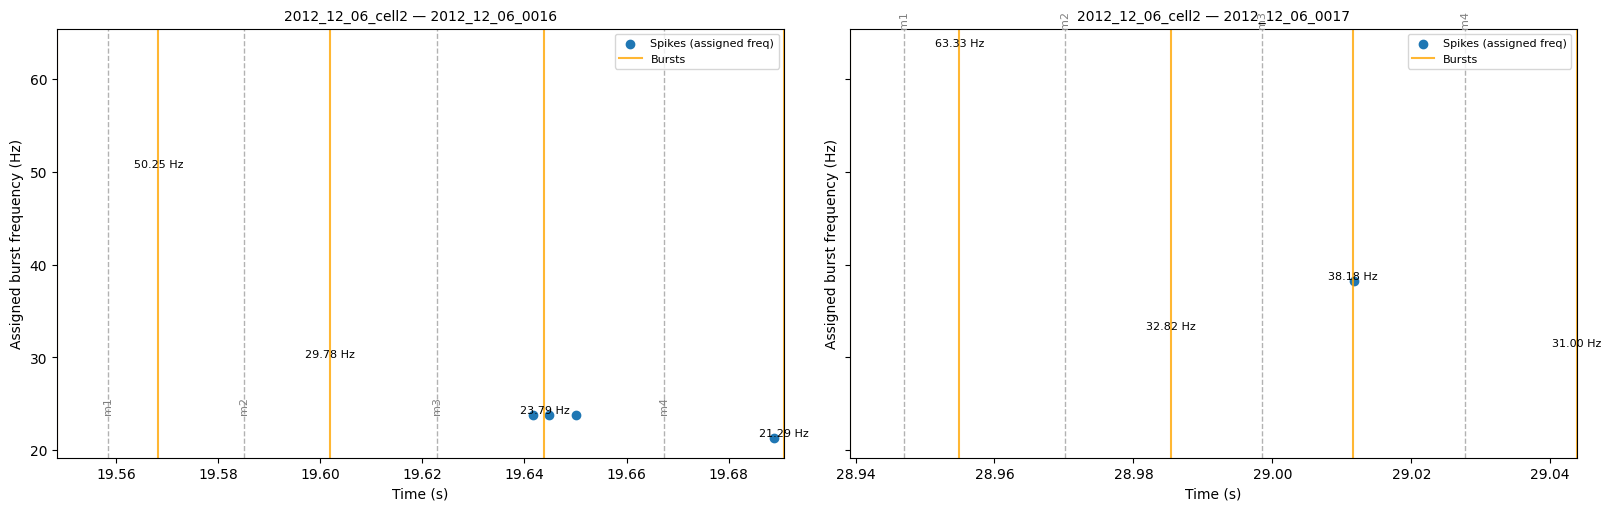

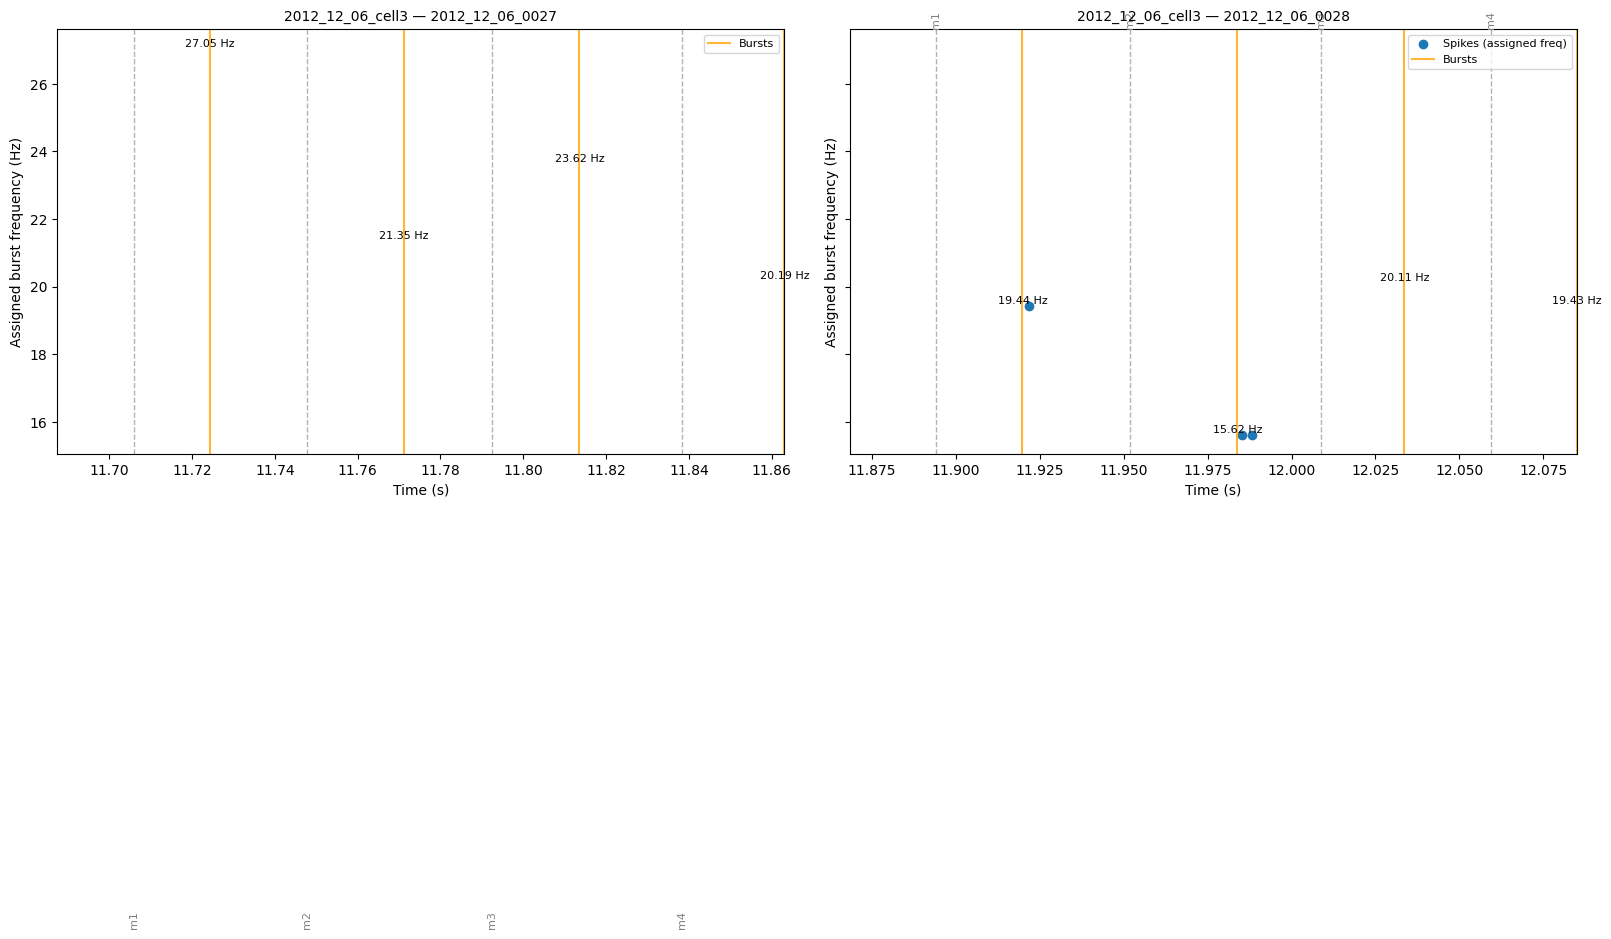

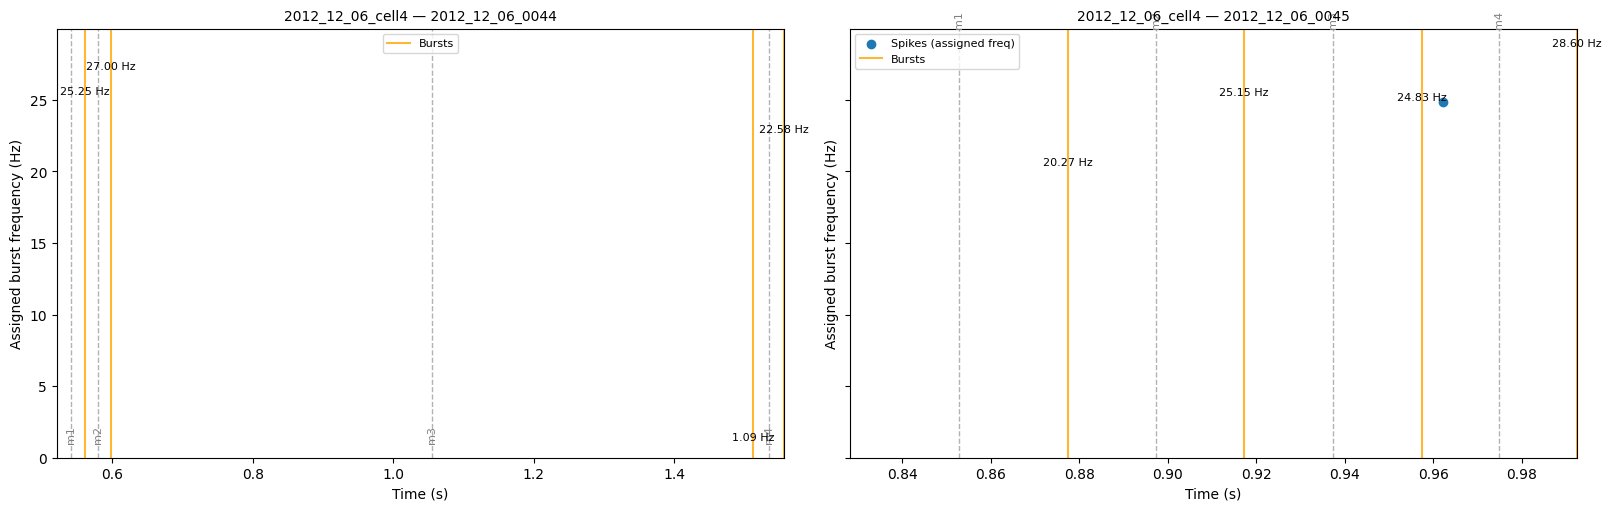

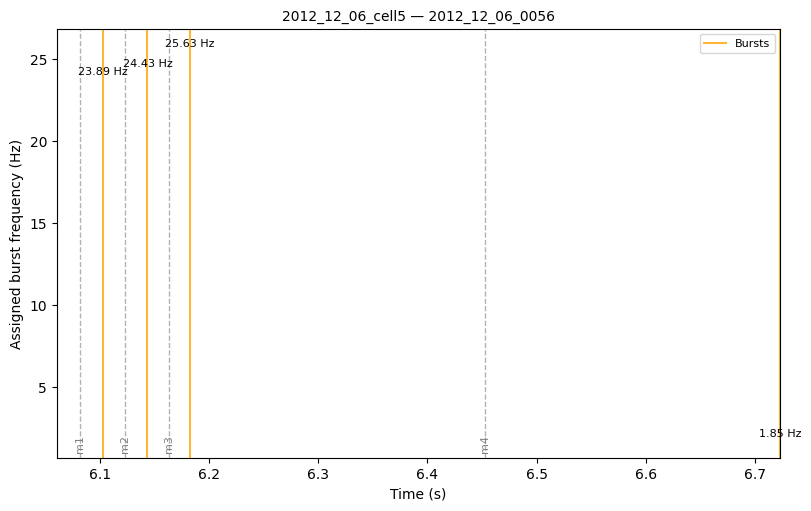

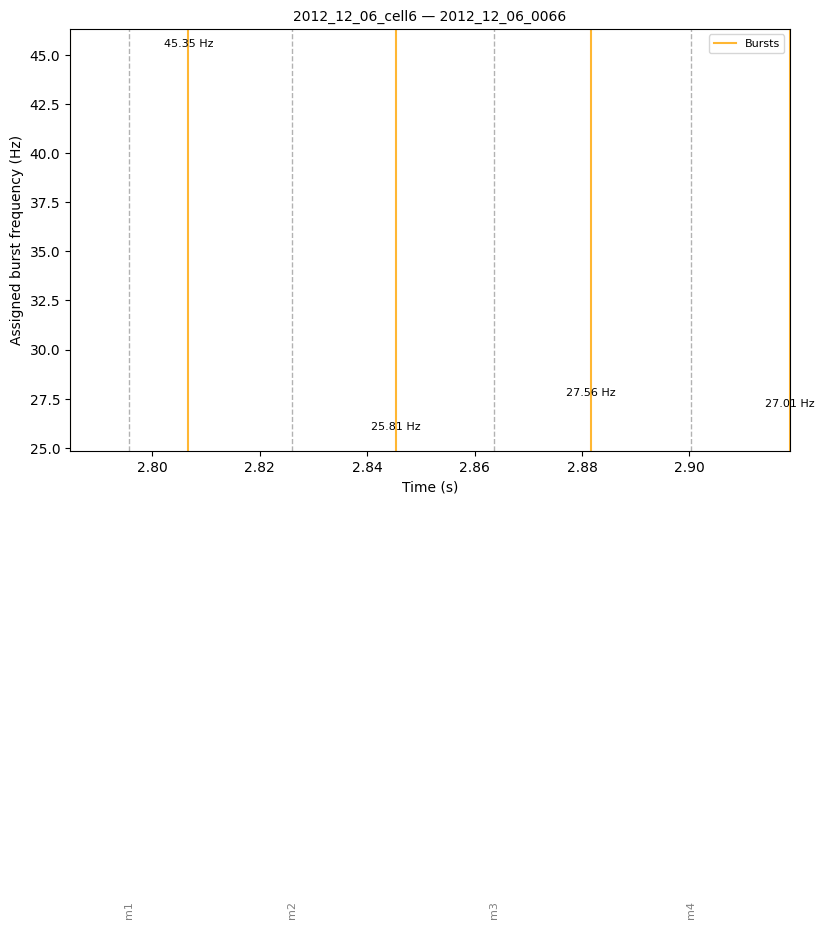

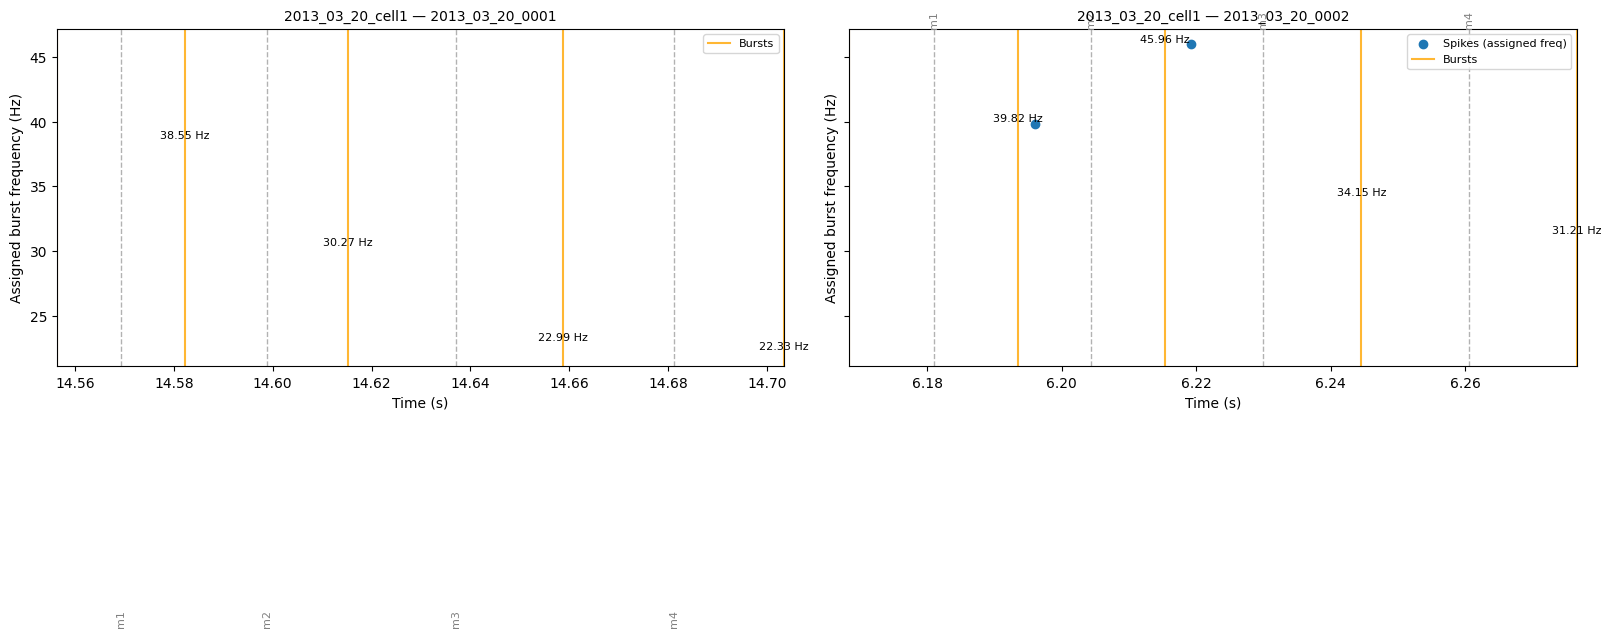

/Users/Haley/Desktop/murray-neuroscience-lab/neuro-venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


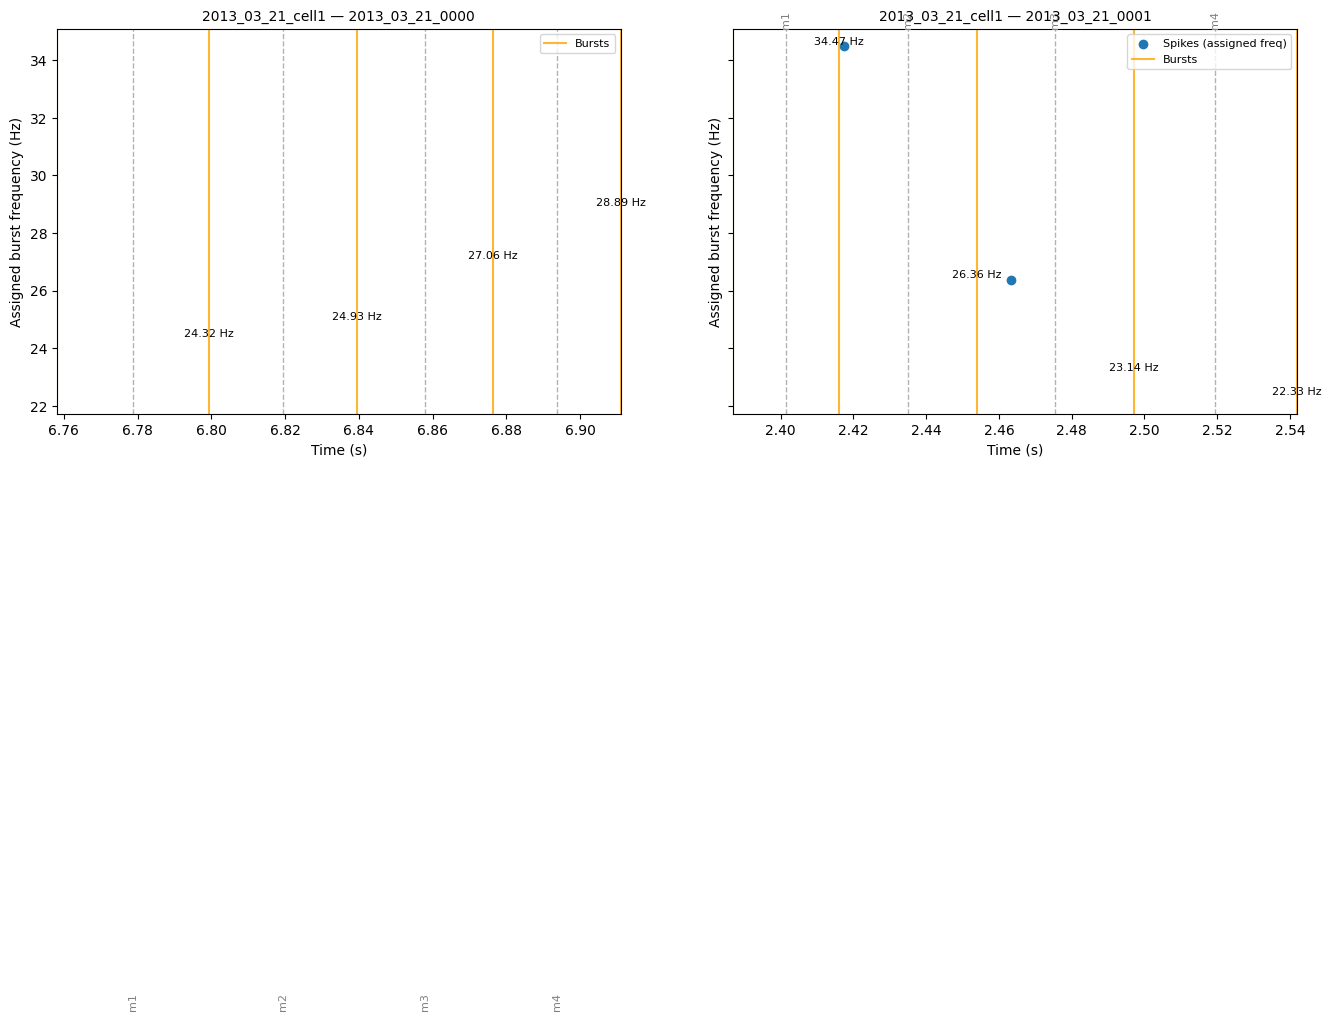

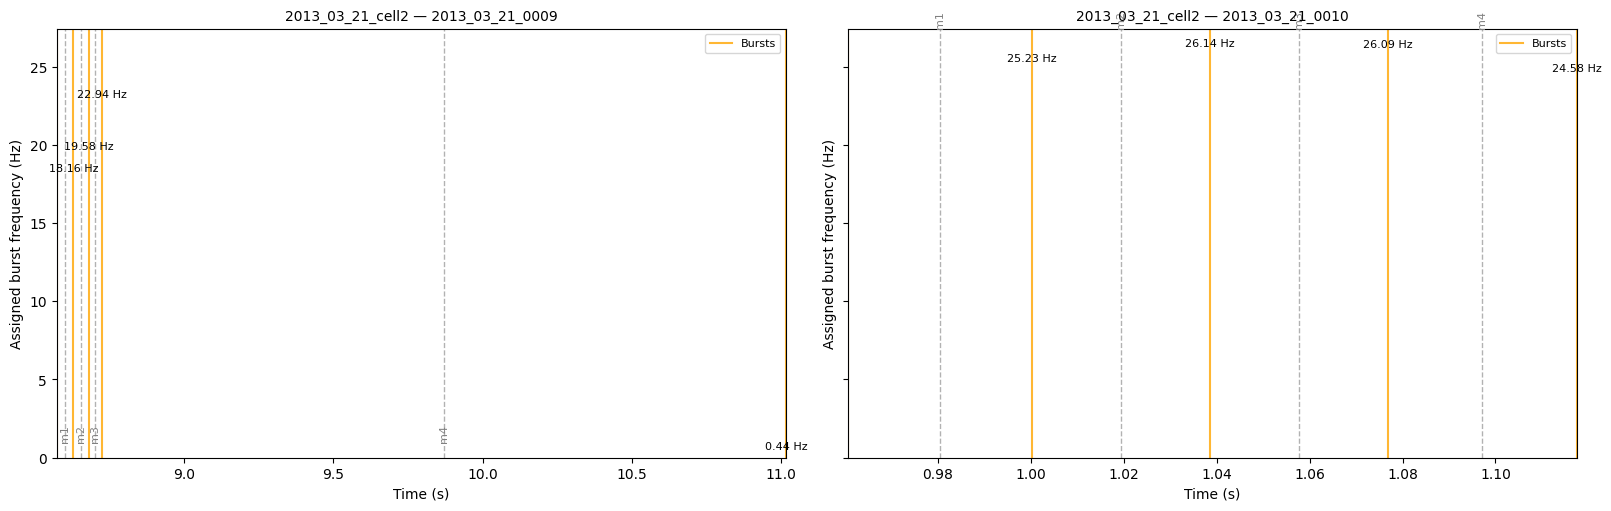

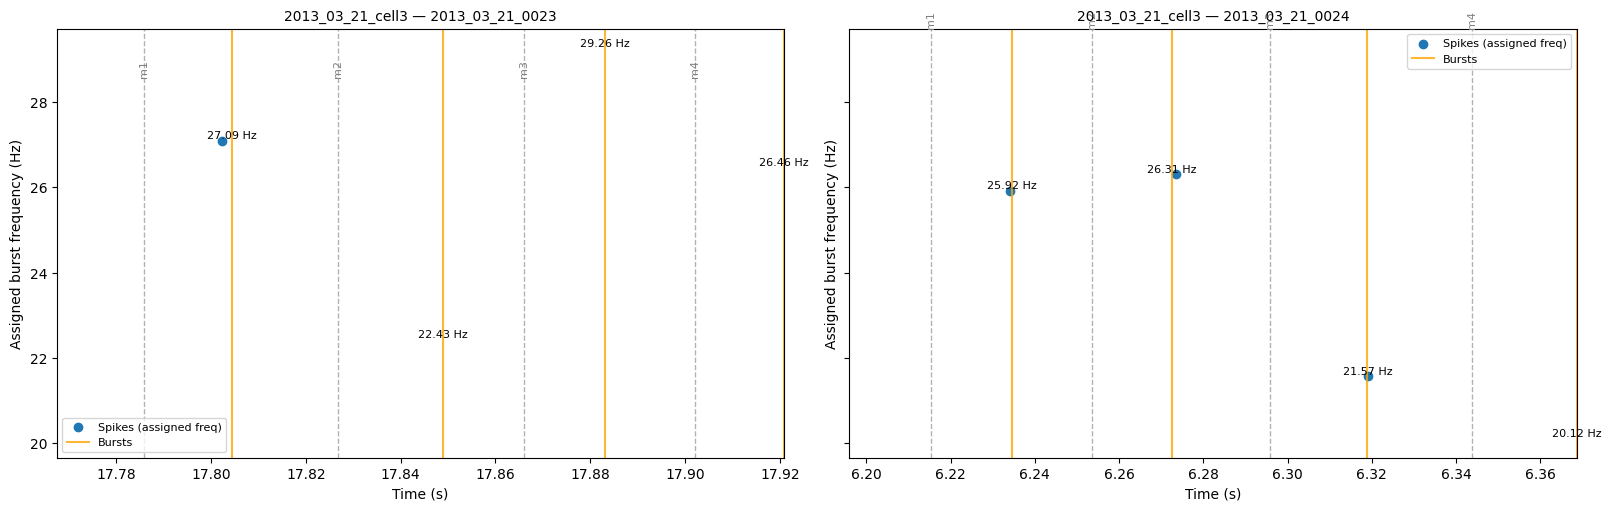

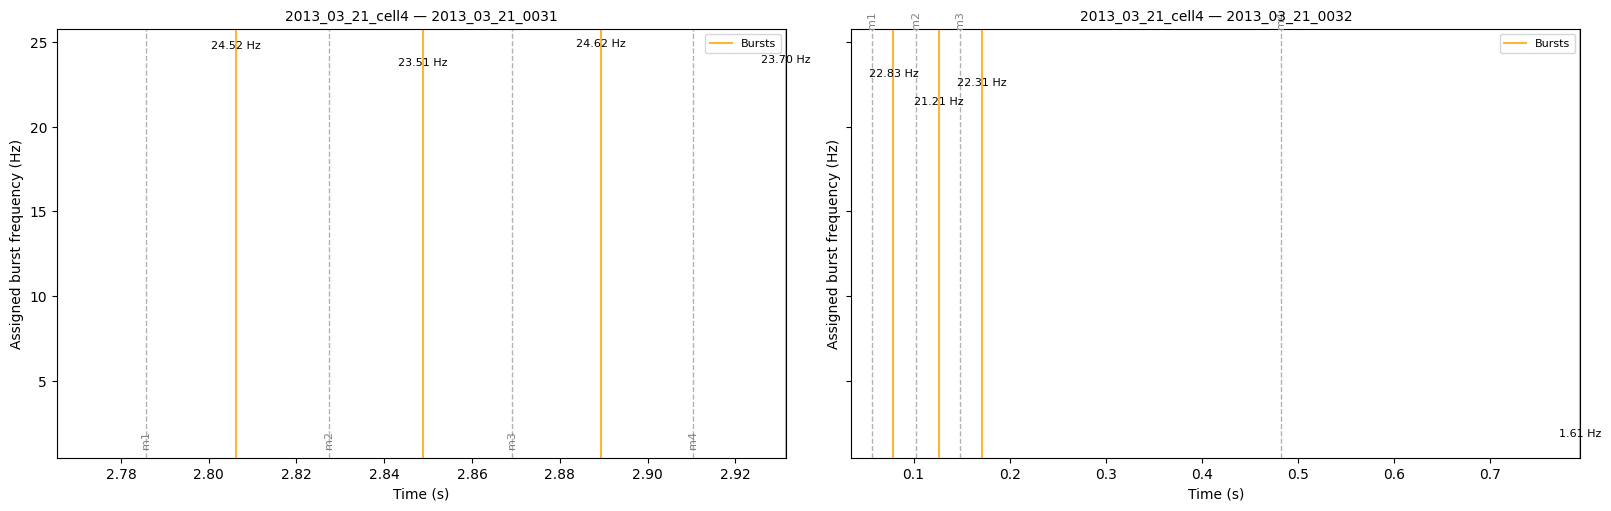

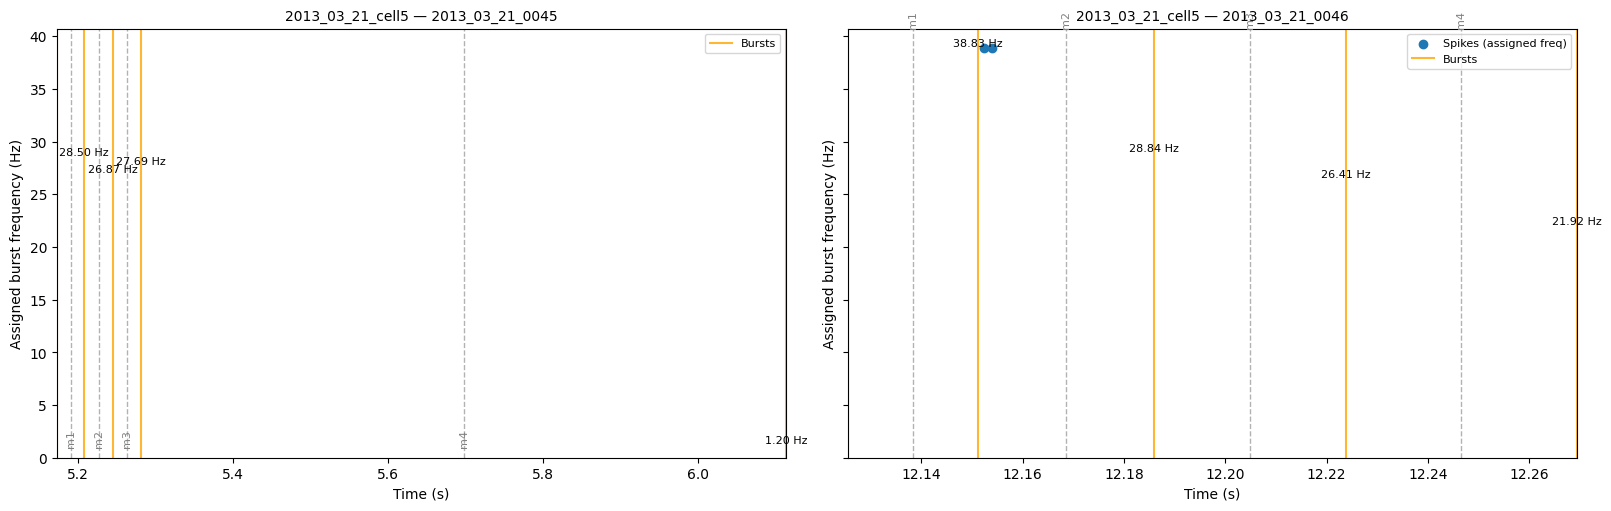

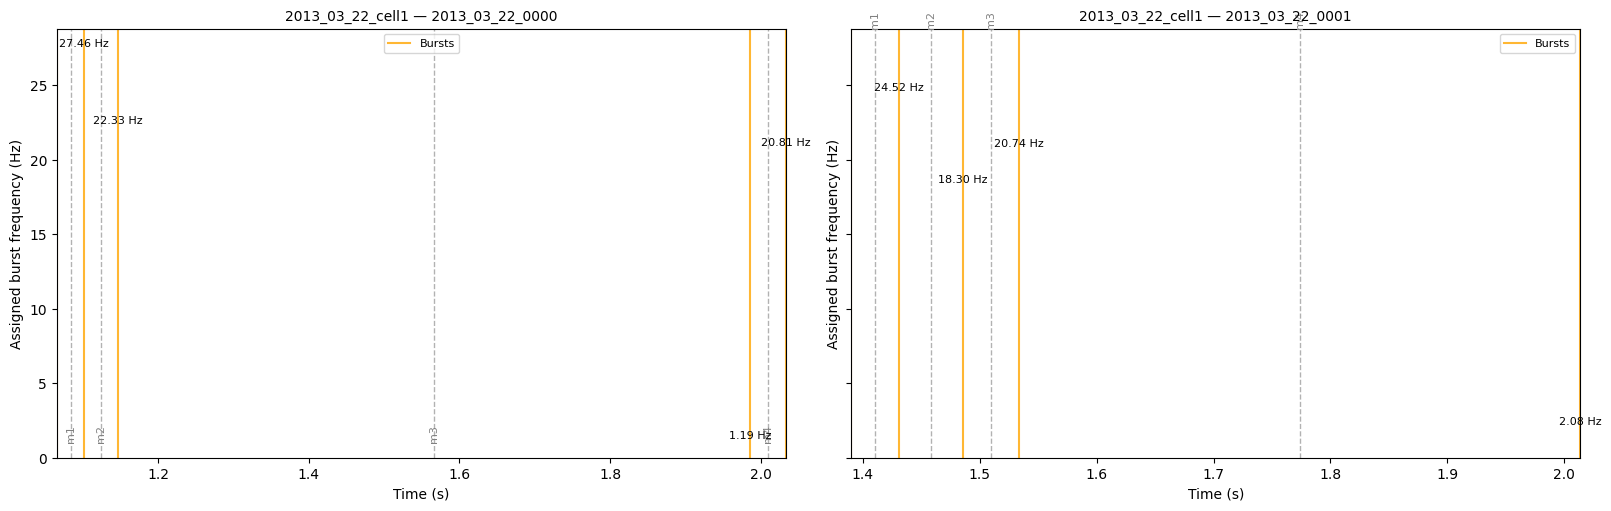

/Users/Haley/Desktop/murray-neuroscience-lab/neuro-venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


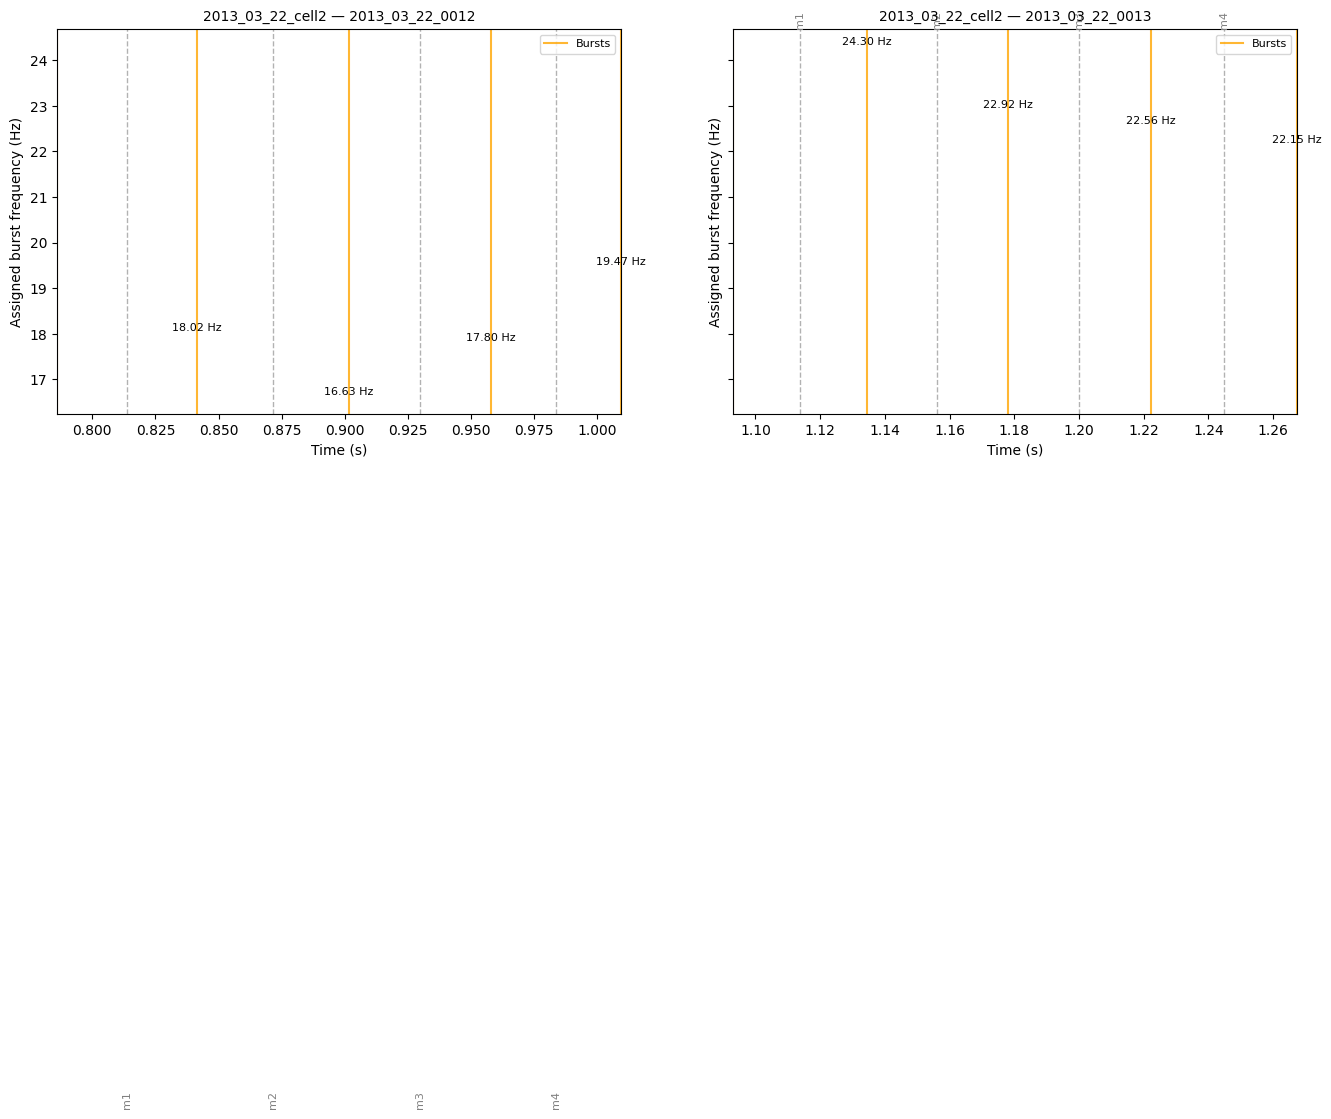

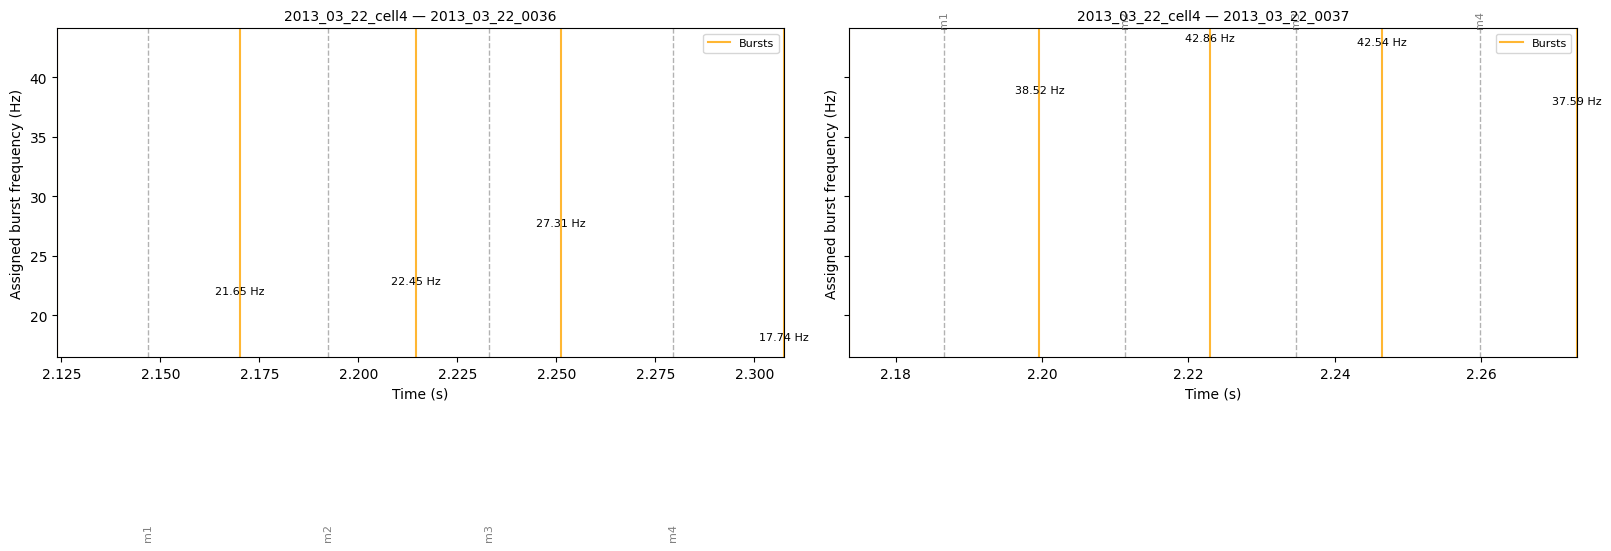

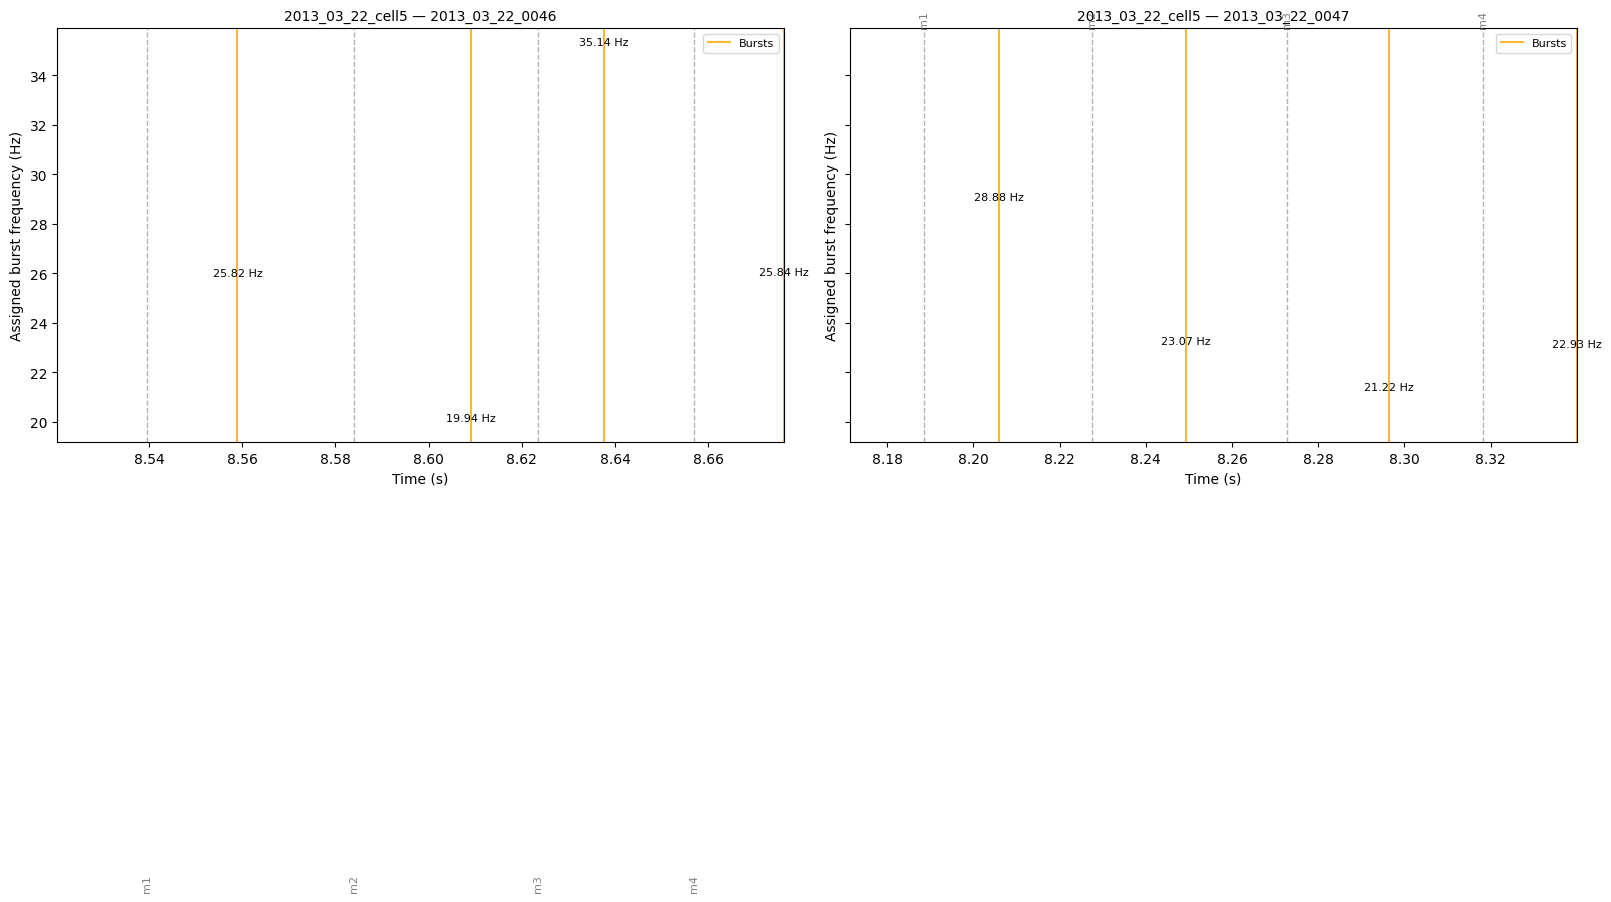

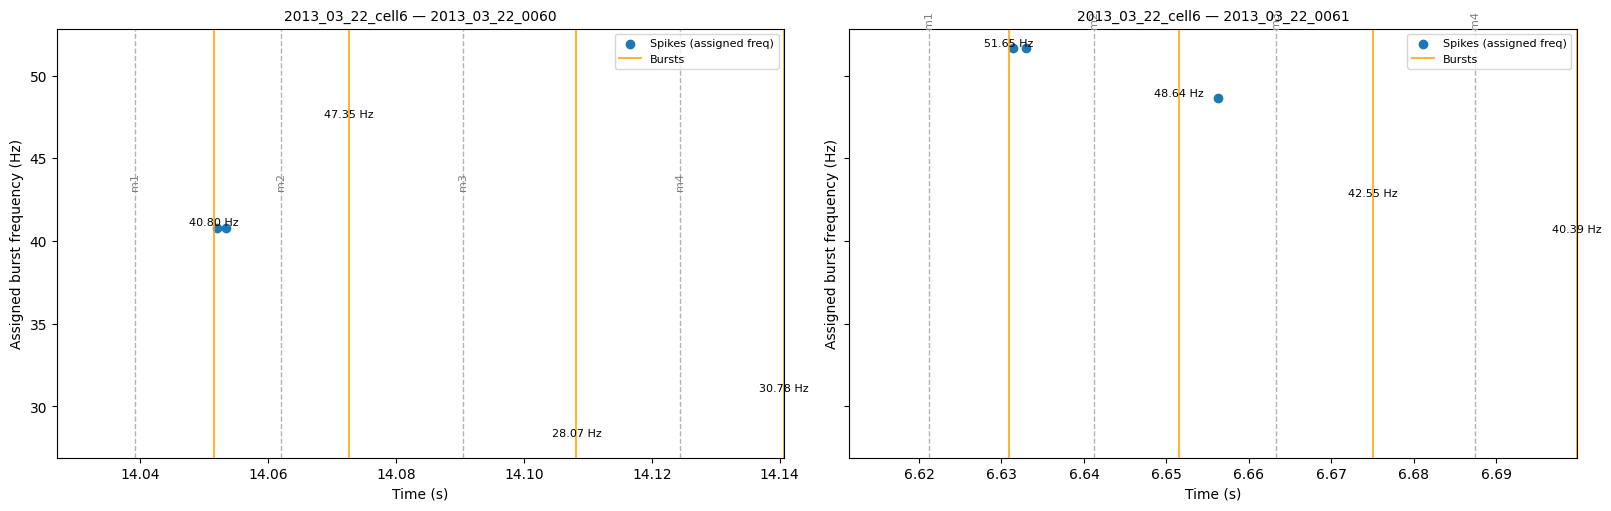

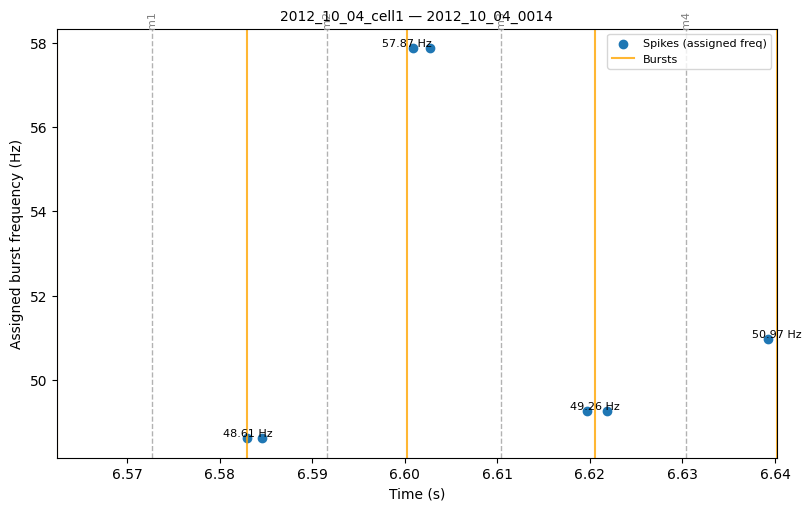

In [ ]:
for sheet_name, sdf in cell_attached_dict.items():
    plot_sheet_first5_bursts(sdf, title_prefix=sheet_name)
